# Clustering of all data

Read in all necessary packages:

In [37]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_99599/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [38]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

In [7]:
for_venn = pd.read_csv('../data/peter/Fig4_incANOVA_full_table-2.csv', sep = '\t', index_col = 0)

In [14]:
for_venn[[ 'name', 'Lin', 'rep', 'gene',
       'prom',  'prom_type' , 'biotype']].head(5)

,name,Lin,rep,gene,prom,prom_type,biotype
0,A330023F24Rik:1,ESC,1,A330023F24Rik,1,main_an,lncRNA
1,A330023F24Rik:2,ESC,1,A330023F24Rik,2,other,lncRNA
2,A330023F24Rik:3,ESC,1,A330023F24Rik,3,main_an,lncRNA
3,A330023F24Rik:1,ESC,2,A330023F24Rik,1,main_an,lncRNA
4,A330023F24Rik:2,ESC,2,A330023F24Rik,2,other,lncRNA


In [22]:
for_venn_filtered1 = for_venn[for_venn['K4_state_avg_round'] == 1]

In [23]:
for_venn_filtered = for_venn_filtered1.drop_duplicates(subset=['name','Lin'], keep='first')

In [25]:
for_venn.shape

(1030100, 49)

In [26]:
for_venn_filtered.shape

(73987, 49)

In [24]:
for_venn_filtered.head(5)

,K4_prom_p,K4_prom_min,K4_prom_max,K4_prom_mean,K4_prom_fold,name,Unnamed: 0,Lin,rep,K4_sum,...,RNA_gene_min,RNA_gene_max,RNA_gene_mean,RNA_gene_fold,K4_state_avg_round,K4_state_gene_max,RNA_state_avg_round,biotype,K4_state_gene_max_sum,K4_prom_sum
0,4.769378,24.2,43.4,31.44,0.817136,A330023F24Rik:1,0,ESC,1,27.0,...,96.4,1634.0,742.4,4.069225,1.0,1.0,1.0,lncRNA,1.0,786.0
15,4.769378,24.2,43.4,31.44,0.817136,A330023F24Rik:1,15,PLU,1,30.0,...,96.4,1634.0,742.4,4.069225,1.0,1.0,1.0,lncRNA,1.0,786.0
30,4.769378,24.2,43.4,31.44,0.817136,A330023F24Rik:1,30,ECT,1,22.0,...,96.4,1634.0,742.4,4.069225,1.0,1.0,1.0,lncRNA,1.0,786.0
45,4.769378,24.2,43.4,31.44,0.817136,A330023F24Rik:1,45,END,1,36.0,...,96.4,1634.0,742.4,4.069225,1.0,1.0,1.0,lncRNA,1.0,786.0
60,4.769378,24.2,43.4,31.44,0.817136,A330023F24Rik:1,60,MES,1,27.0,...,96.4,1634.0,742.4,4.069225,1.0,1.0,1.0,lncRNA,1.0,786.0


In [9]:
for_venn.columns

Index(['K4_prom_p', 'K4_prom_min', 'K4_prom_max', 'K4_prom_mean',
       'K4_prom_fold', 'name', 'Unnamed: 0', 'Lin', 'rep', 'K4_sum', 'gene',
       'prom', 'RNA_sum', 'RNA_gene_sum', 'K4_log2', 'RNA_log2',
       'RNA_gene_log2', 'K4_state', 'RNA_gene_state', 'max_prom',
       'ever_expressed', 'ever_K4', 'Lin_expressed', 'Lin_K4',
       'RNA_genewise_max', 'RNA_rel', 'pos_prom_count', 'prom_ever_K4',
       'K4_state_avg', 'prom_type', 'RNA_gene_max_state', 'index_x',
       'RNA_prom_p', 'RNA_prom_min', 'RNA_prom_max', 'RNA_prom_mean',
       'RNA_prom_fold', 'index_y', 'RNA_gene_p', 'RNA_gene_min',
       'RNA_gene_max', 'RNA_gene_mean', 'RNA_gene_fold', 'K4_state_avg_round',
       'K4_state_gene_max', 'RNA_state_avg_round', 'biotype',
       'K4_state_gene_max_sum', 'K4_prom_sum'],
      dtype='object')

In [29]:
venn_diagram = pd.DataFrame(for_venn_filtered['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})

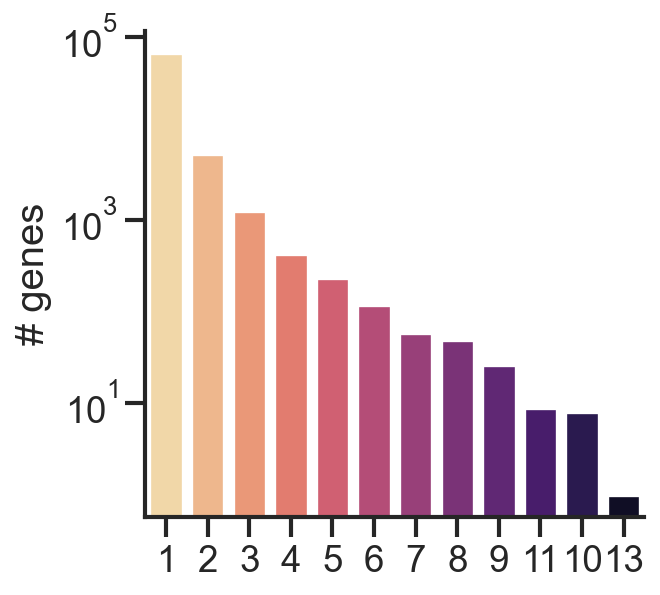

In [30]:
vals = pd.DataFrame(venn_diagram['promoter'].value_counts())

sns.barplot(x = vals.index, y = vals['promoter'], palette = 'magma_r', )
sns.despine()
plt.ylabel('# genes')           
plt.yscale('log')
plt.legend([],frameon=False)

In [33]:
for_venn_filtered[for_venn_filtered['Lin'] == 'ESC']

,K4_prom_p,K4_prom_min,K4_prom_max,K4_prom_mean,K4_prom_fold,name,Unnamed: 0,Lin,rep,K4_sum,...,RNA_gene_min,RNA_gene_max,RNA_gene_mean,RNA_gene_fold,K4_state_avg_round,K4_state_gene_max,RNA_state_avg_round,biotype,K4_state_gene_max_sum,K4_prom_sum
0,4.769378,24.2,43.4,31.44,0.817136,A330023F24Rik:1,0,ESC,1,27.0,...,96.4,1634.0,742.40,4.069225,1.0,1.0,1.0,lncRNA,1.0,786.0
75,10.665862,41.6,98.8,56.76,1.228186,Ubr3:1,75,ESC,1,108.0,...,2880.6,4758.4,3741.84,0.723910,1.0,1.0,1.0,protein_coding,1.0,1419.0
200,9.911789,26.6,104.6,45.20,1.935870,Ybx2:1,200,ESC,1,86.0,...,38.0,100.2,69.76,1.375663,1.0,1.0,1.0,protein_coding,1.0,1130.0
250,9.059728,44.2,80.8,68.56,0.855778,Atl1:1,250,ESC,1,59.0,...,115.4,249.0,167.92,1.102837,1.0,1.0,1.0,protein_coding,2.0,1714.0
251,7.599437,6.2,43.0,15.24,2.611435,Atl1:2,251,ESC,1,52.0,...,115.4,249.0,167.92,1.102837,1.0,1.0,1.0,protein_coding,2.0,381.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029975,9.256704,5.6,34.0,13.64,2.406817,Cox8b:1,1029975,ESC,1,35.0,...,0.0,0.8,0.48,0.847997,1.0,1.0,0.0,protein_coding,1.0,341.0
1030000,14.827747,38.4,293.0,119.92,2.899549,Ifitm2:1,1030000,ESC,1,285.0,...,30.4,146.4,80.64,2.230900,1.0,1.0,1.0,protein_coding,1.0,2998.0
1030025,10.258357,41.6,120.6,67.52,1.513218,Kremen2:1,1030025,ESC,1,125.0,...,1.4,17.8,8.32,2.969626,1.0,1.0,0.0,protein_coding,1.0,1688.0
1030050,10.112485,2.0,30.0,9.36,3.369234,Gstm3:1,1030050,ESC,1,30.0,...,0.6,12.8,4.16,3.108524,1.0,1.0,0.0,protein_coding,1.0,234.0


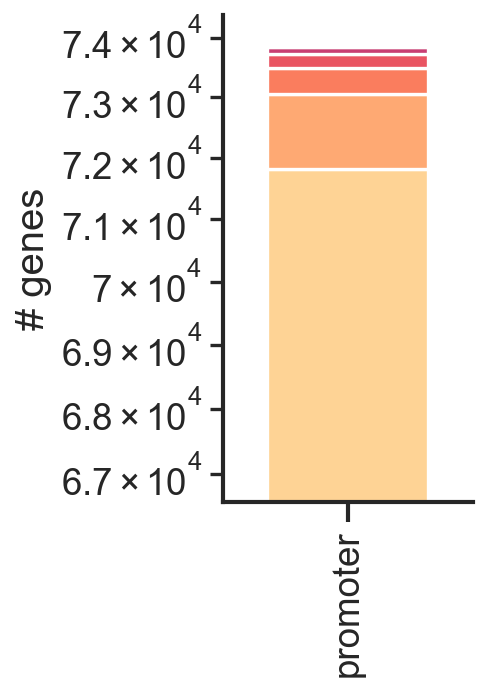

In [39]:
vals.T.plot.bar(stacked=True,width = 0.9, figsize = (2,4),
                cmap = 'magma_r')
plt.yscale('log')
plt.ylabel('# genes')
plt.legend([],frameon=False)
sns.despine()

In [42]:
sc.set_figure_params(dpi = 150)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

font1 = {'family':'helvetica','color':'black','size':16} # use for title
font2 = {'family': 'helvetica', 'size': 8.5} # use for labels
plt.rc('font', **font2) # sets the default font 
plt.rcParams['text.color'] = 'black' # changes default text colour


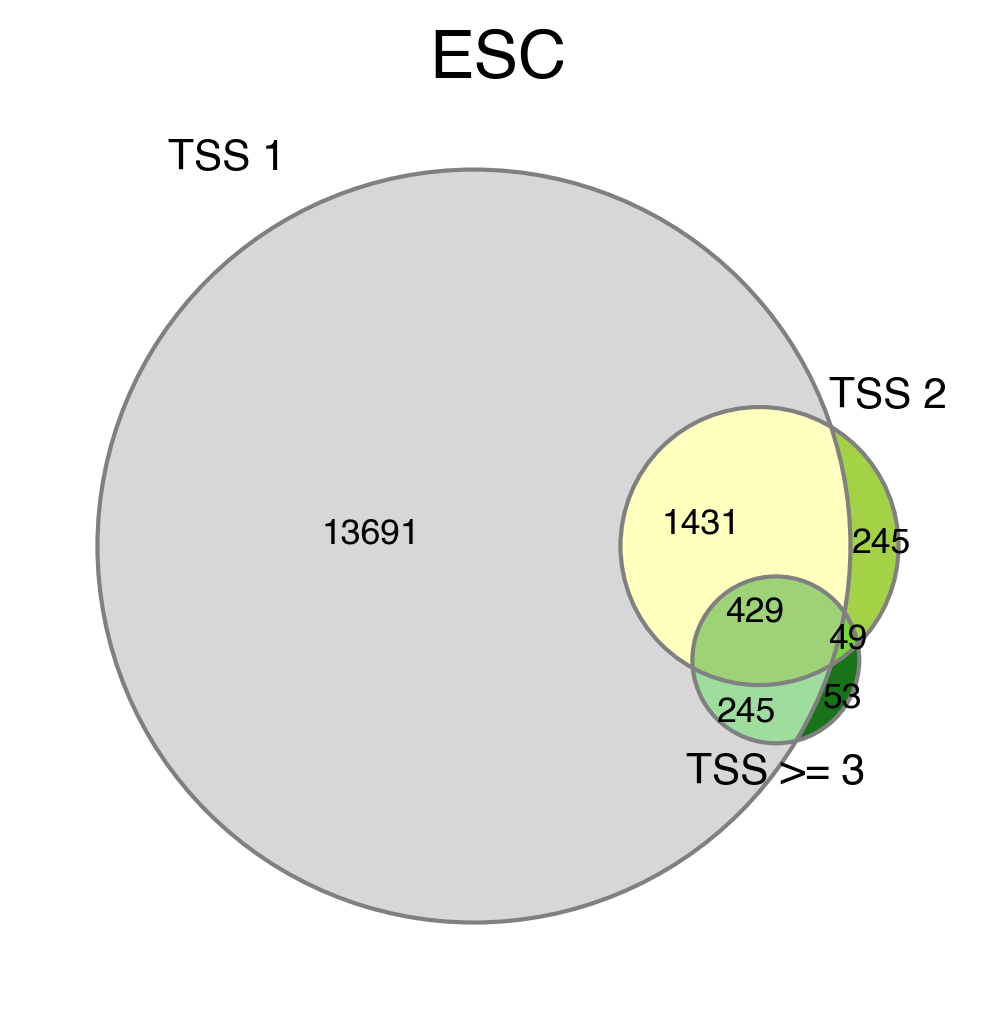

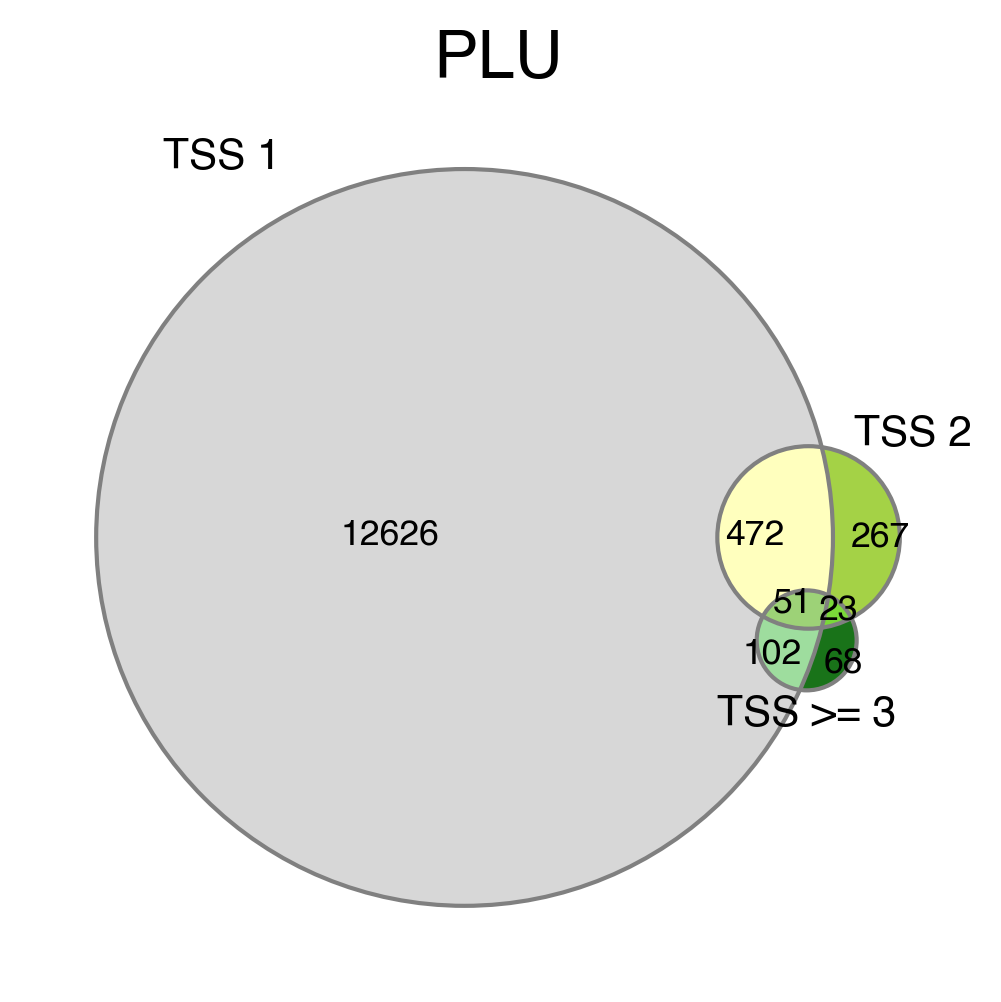

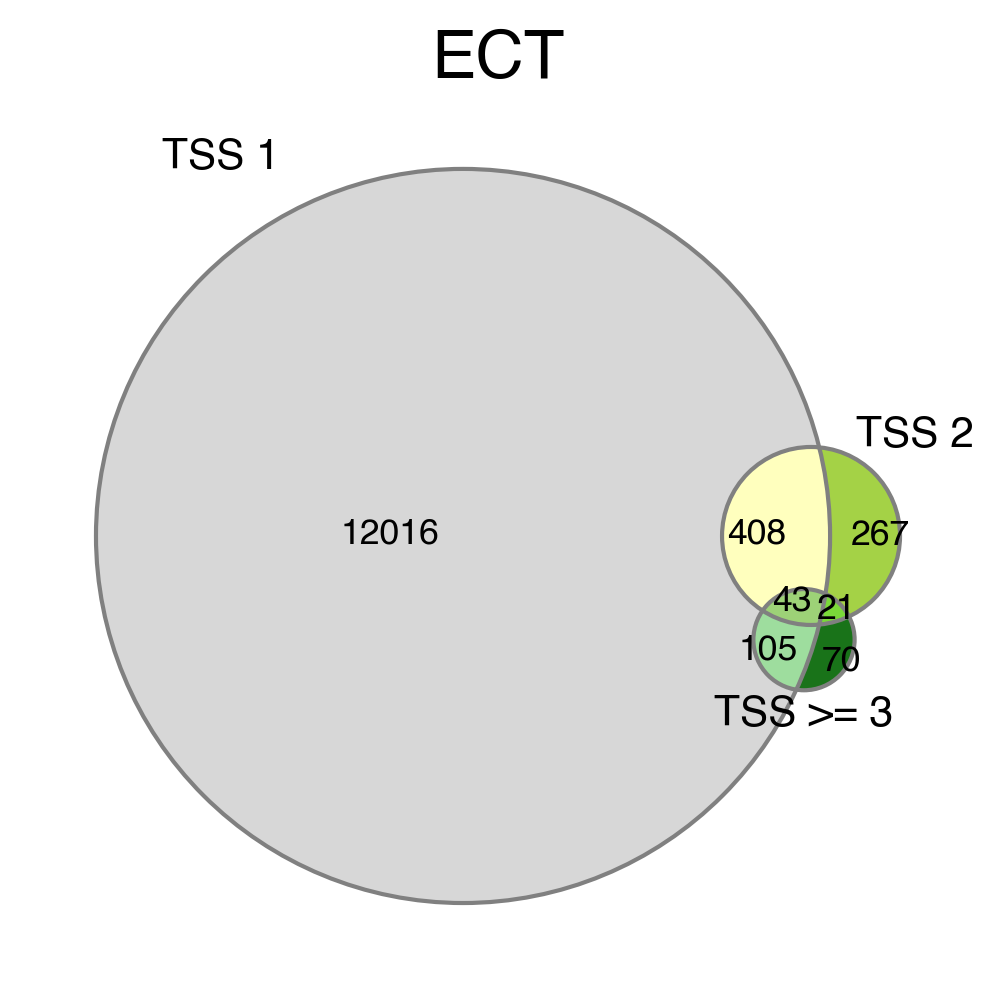

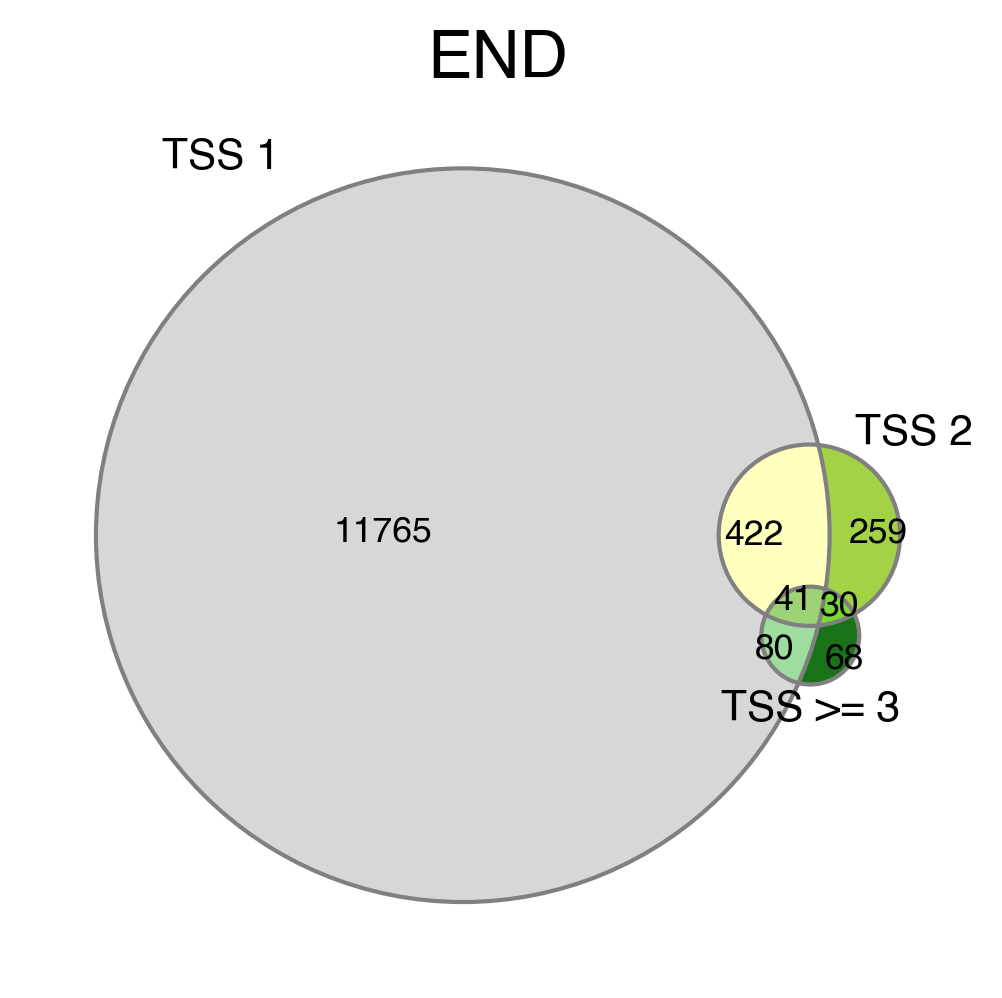

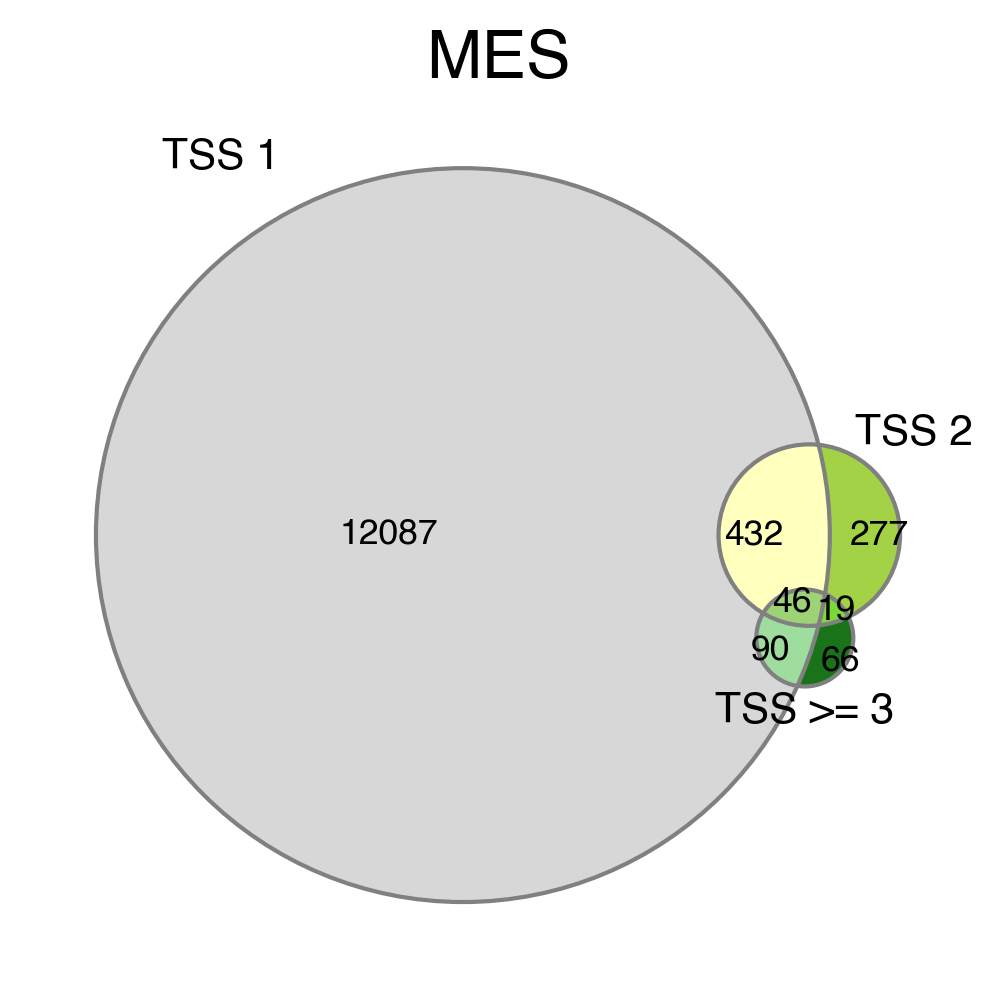

In [43]:
for ct in for_venn_filtered['Lin'].unique():
    venn_ct = for_venn_filtered[for_venn_filtered['Lin'] == ct]
    venn_diagram = pd.DataFrame(venn_ct['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})
    a = list(venn_diagram[venn_diagram['promoter'] == '1']['gene'])
    b = list(venn_diagram[venn_diagram['promoter'] == '2']['gene'])
    c = list(venn_diagram[(venn_diagram['promoter'] != '1') & (venn_diagram['promoter'] != '2') ]['gene'])



    venn3([set(a),set(b),set(c)], set_labels = ('TSS 1','TSS 2','TSS >= 3'),
          set_colors=['lightgrey','yellowgreen','darkgreen'], alpha = 0.9,)
    venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
    plt.title(ct, fontdict=font1)
    plt.show()



    
    

In [52]:
for_venn_filtered['Lin'].unique()

array(['ESC', 'PLU', 'ECT', 'END', 'MES'], dtype=object)

In [62]:
venn_diagram = for_venn_filtered[['Lin', 'gene','prom']]
venn_diagram.head(5)

,Lin,gene,prom
0,ESC,A330023F24Rik,1
15,PLU,A330023F24Rik,1
30,ECT,A330023F24Rik,1
45,END,A330023F24Rik,1
60,MES,A330023F24Rik,1


In [71]:
prom_1[(prom_1['Lin'] == 'ECT') | (prom_1['Lin'] == 'END') | (prom_1['Lin'] == 'MES') ]

,Lin,gene,prom
30,ECT,A330023F24Rik,1
45,END,A330023F24Rik,1
60,MES,A330023F24Rik,1
125,ECT,Ubr3,1
150,END,Ubr3,1
...,...,...,...
1030040,END,Kremen2,1
1030045,MES,Kremen2,1
1030085,ECT,Pde12,1
1030090,END,Pde12,1


In [105]:
sns.color_palette(['#3787c0', '#fc6832', '#df2179', '#58b669'])

[(0.21568627450980393, 0.5294117647058824, 0.7529411764705882),
 (0.9882352941176471, 0.40784313725490196, 0.19607843137254902),
 (0.8745098039215686, 0.12941176470588237, 0.4745098039215686),
 (0.34509803921568627, 0.7137254901960784, 0.4117647058823529)]

In [268]:
sns.color_palette(['#d6e6f4', '#abd0e6', '#6aaed6', '#3787c0', '#105ba4', '#ffea9b', 
                   '#fece6a', '#fea245', '#fc6832', '#ea2920', '#c20325', '#e1d4e8', '#cda0cd', '#df64af', '#df2179', '#a90649', '#f3fab6', '#ccea9d', 
                   
                   '#97d385', '#58b669', '#2c8f4b', '#056c39'])

[(0.8392156862745098, 0.9019607843137255, 0.9568627450980393),
 (0.6705882352941176, 0.8156862745098039, 0.9019607843137255),
 (0.41568627450980394, 0.6823529411764706, 0.8392156862745098),
 (0.21568627450980393, 0.5294117647058824, 0.7529411764705882),
 (0.06274509803921569, 0.3568627450980392, 0.6431372549019608),
 (1.0, 0.9176470588235294, 0.6078431372549019),
 (0.996078431372549, 0.807843137254902, 0.41568627450980394),
 (0.996078431372549, 0.6352941176470588, 0.27058823529411763),
 (0.9882352941176471, 0.40784313725490196, 0.19607843137254902),
 (0.9176470588235294, 0.1607843137254902, 0.12549019607843137),
 (0.7607843137254902, 0.011764705882352941, 0.1450980392156863),
 (0.8823529411764706, 0.8313725490196079, 0.9098039215686274),
 (0.803921568627451, 0.6274509803921569, 0.803921568627451),
 (0.8745098039215686, 0.39215686274509803, 0.6862745098039216),
 (0.8745098039215686, 0.12941176470588237, 0.4745098039215686),
 (0.6627450980392157, 0.023529411764705882, 0.28627450980392155),
 (0.9529411764705882, 0.9803921568627451, 0.7137254901960784),
 (0.8, 0.9176470588235294, 0.615686274509804),
 (0.592156862745098, 0.8274509803921568, 0.5215686274509804),
 (0.34509803921568627, 0.7137254901960784, 0.4117647058823529),
 (0.17254901960784313, 0.5607843137254902, 0.29411764705882354),
 (0.0196078431372549, 0.4235294117647059, 0.2235294117647059)]

In [106]:
sns.color_palette(['#1f77b4', '#ff7f0e', '#279e68', '#d62728', '#aa40fc', '#8c564b', '#e377c2', '#b5bd61', '#17becf', '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#c49c94'])

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.15294117647058825, 0.6196078431372549, 0.40784313725490196),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.6666666666666666, 0.25098039215686274, 0.9882352941176471),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.7098039215686275, 0.7411764705882353, 0.3803921568627451),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529),
 (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 (1.0, 0.7333333333333333, 0.47058823529411764),
 (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 (1.0, 0.596078431372549, 0.5882352941176471),
 (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451)]

In [107]:
sns.color_palette(['#008080', '#3cb371', '#228b22', '#98fb98', '#9acd32', '#20b2aa', '#ff69b4', '#d2691e', '#ffd700', '#ff6347', '#d8bfd8', '#4169e1', '#8a2be2', '#00ffff', '#ffe4e1', 
                   '#dc143c', '#708090', '#ff8c00', '#cd5c5c', '#b0c4de', '#adff2f', '#dda0dd', '#00bfff', '#000080', '#8b4513', '#4b0082', '#8b0000', '#1e90ff', '#b0e0e6', '#800000', '#2f4f4f'])

[(0.0, 0.5019607843137255, 0.5019607843137255),
 (0.23529411764705882, 0.7019607843137254, 0.44313725490196076),
 (0.13333333333333333, 0.5450980392156862, 0.13333333333333333),
 (0.596078431372549, 0.984313725490196, 0.596078431372549),
 (0.6039215686274509, 0.803921568627451, 0.19607843137254902),
 (0.12549019607843137, 0.6980392156862745, 0.6666666666666666),
 (1.0, 0.4117647058823529, 0.7058823529411765),
 (0.8235294117647058, 0.4117647058823529, 0.11764705882352941),
 (1.0, 0.8431372549019608, 0.0),
 (1.0, 0.38823529411764707, 0.2784313725490196),
 (0.8470588235294118, 0.7490196078431373, 0.8470588235294118),
 (0.2549019607843137, 0.4117647058823529, 0.8823529411764706),
 (0.5411764705882353, 0.16862745098039217, 0.8862745098039215),
 (0.0, 1.0, 1.0),
 (1.0, 0.8941176470588236, 0.8823529411764706),
 (0.8627450980392157, 0.0784313725490196, 0.23529411764705882),
 (0.4392156862745098, 0.5019607843137255, 0.5647058823529412),
 (1.0, 0.5490196078431373, 0.0),
 (0.803921568627451, 0.3607843137254902, 0.3607843137254902),
 (0.6901960784313725, 0.7686274509803922, 0.8705882352941177),
 (0.6784313725490196, 1.0, 0.1843137254901961),
 (0.8666666666666667, 0.6274509803921569, 0.8666666666666667),
 (0.0, 0.7490196078431373, 1.0),
 (0.0, 0.0, 0.5019607843137255),
 (0.5450980392156862, 0.27058823529411763, 0.07450980392156863),
 (0.29411764705882354, 0.0, 0.5098039215686274),
 (0.5450980392156862, 0.0, 0.0),
 (0.11764705882352941, 0.5647058823529412, 1.0),
 (0.6901960784313725, 0.8784313725490196, 0.9019607843137255),
 (0.5019607843137255, 0.0, 0.0),
 (0.1843137254901961, 0.30980392156862746, 0.30980392156862746)]

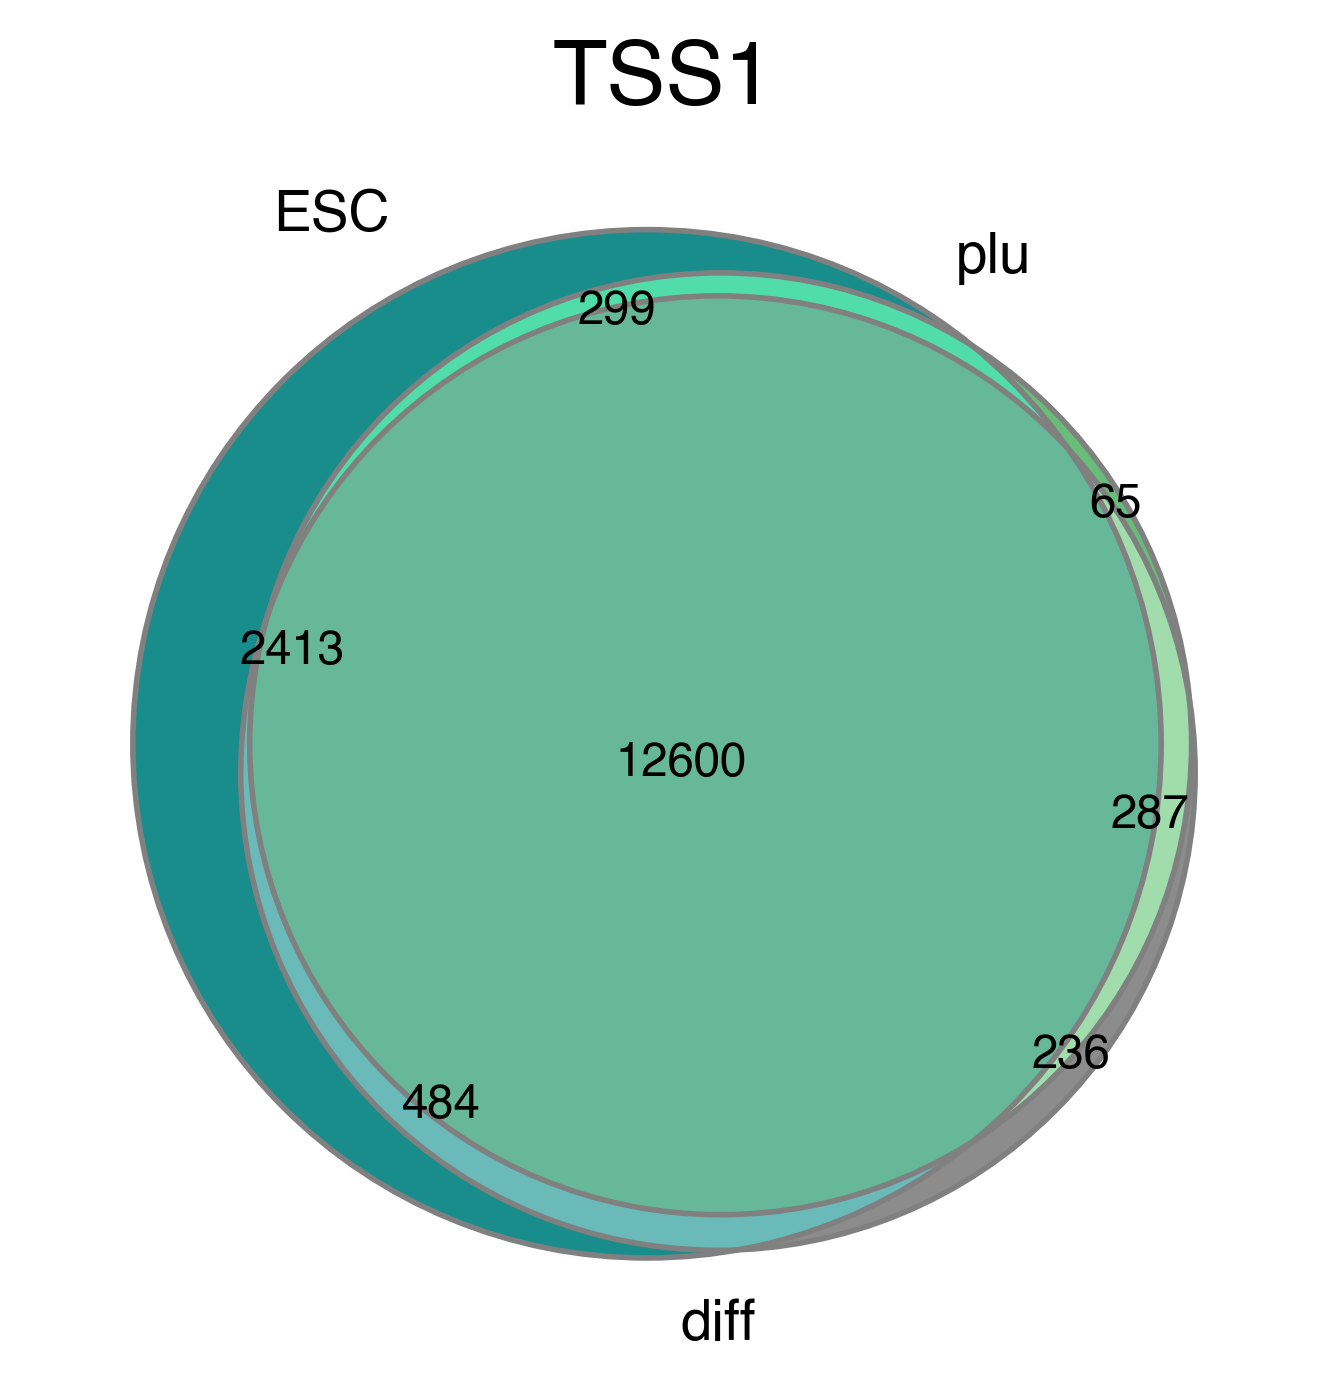

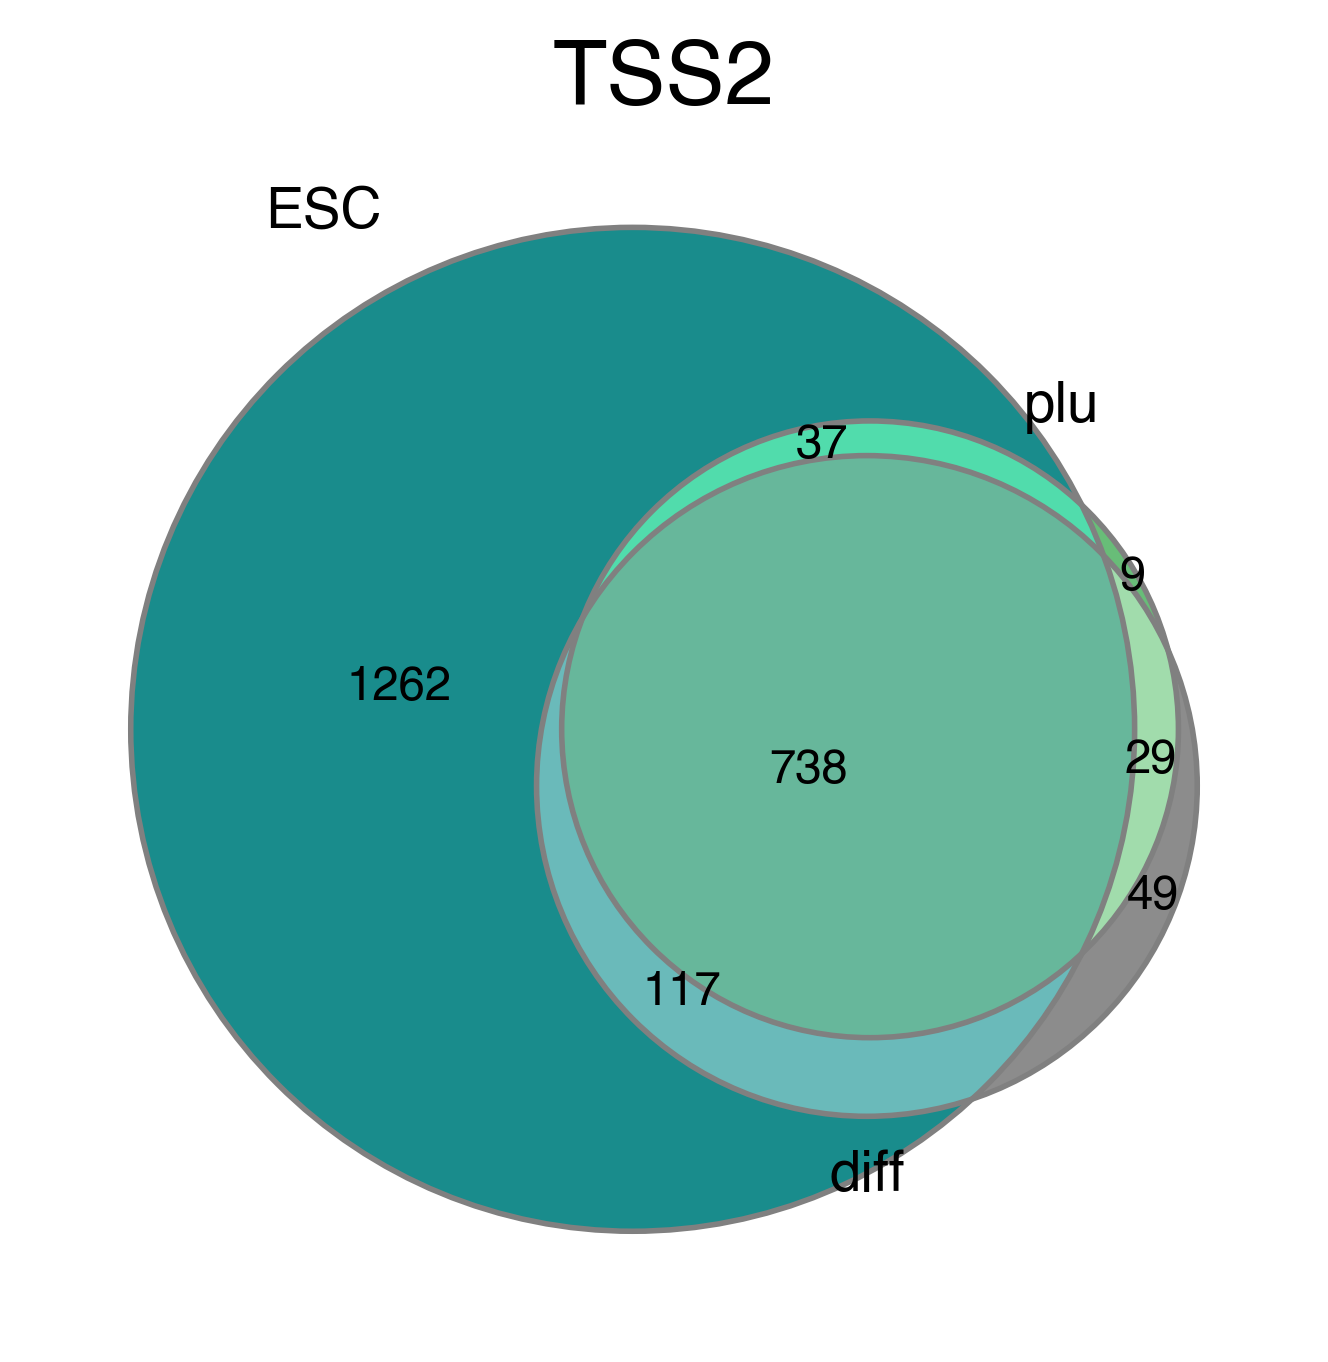

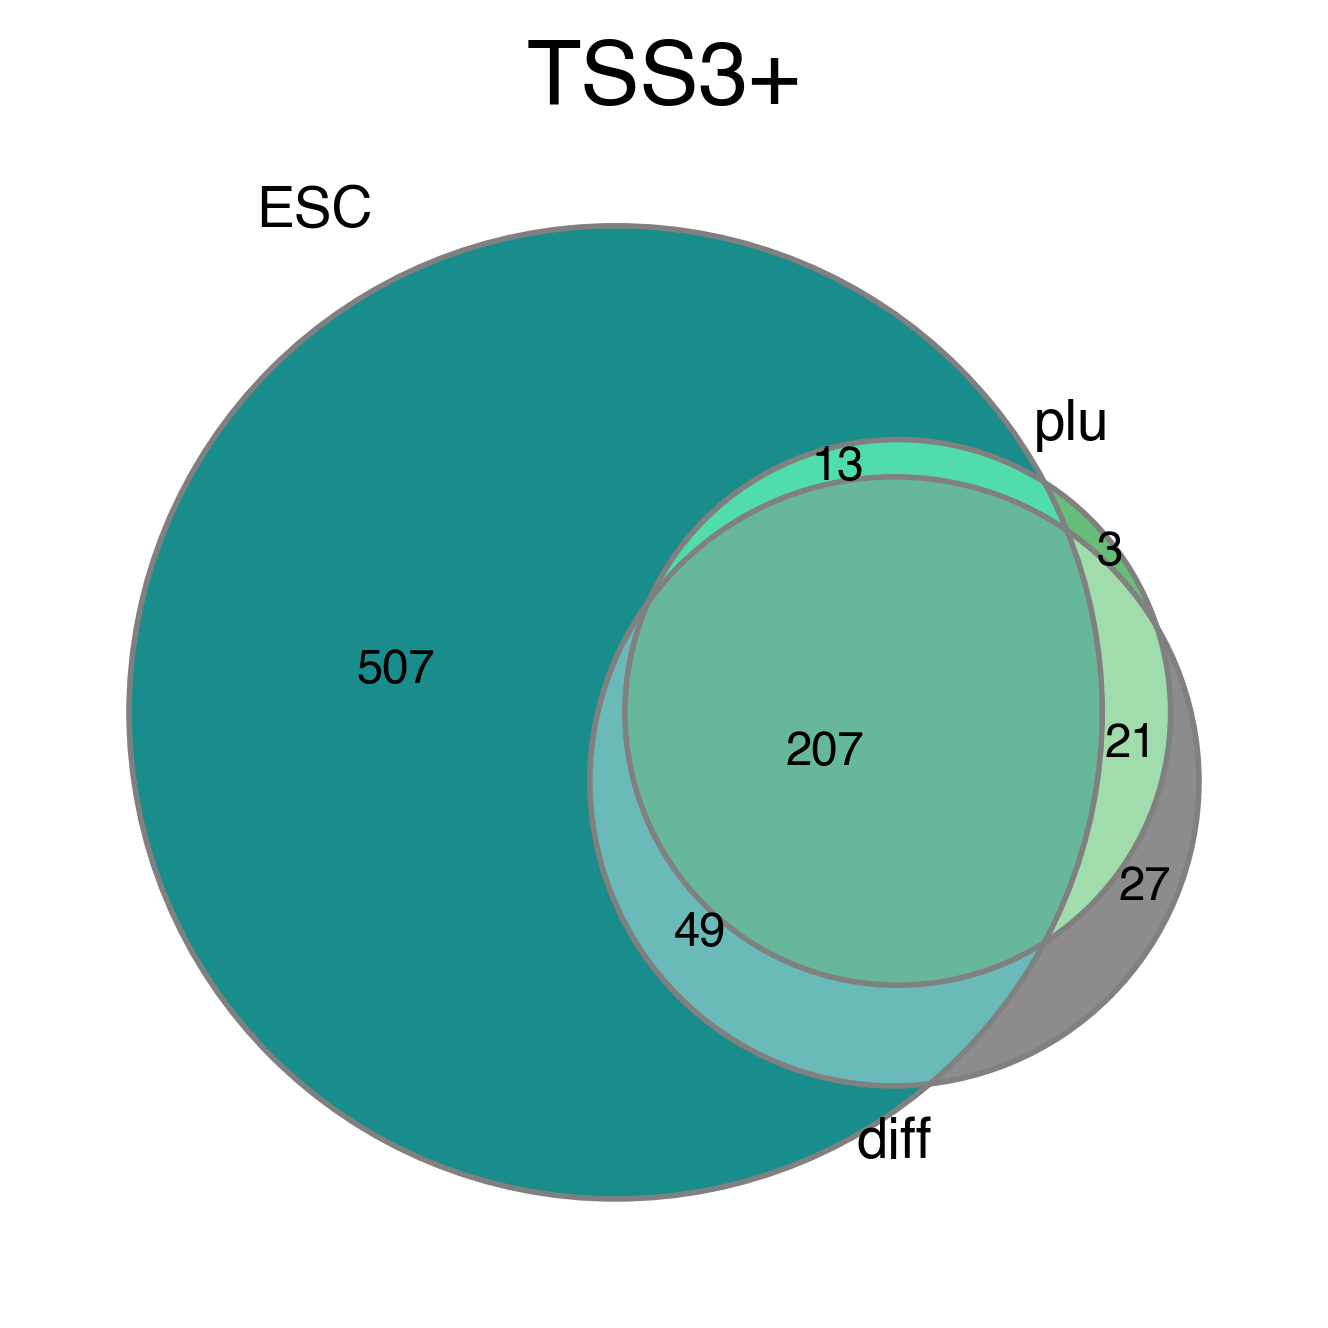

In [108]:
prom_1 = venn_diagram[venn_diagram['prom'] == 1]

a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') | (prom_1['Lin'] == 'END') | (prom_1['Lin'] == 'MES') ] ['gene'].unique())

venn3([set(a),set(b),set(c)], set_labels = ('ESC','plu','diff'),
      set_colors=['#008080','#58b669','grey'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()

prom_2 = venn_diagram[venn_diagram['prom'] == 2]

a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') | (prom_2['Lin'] == 'END') | (prom_2['Lin'] == 'MES') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESC','plu', 'diff'),
      set_colors=['#008080','#58b669','grey'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()

prom_3 = venn_diagram[(venn_diagram['prom'] != 1) & (venn_diagram['prom'] != 2)]

a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') | (prom_3['Lin'] == 'END') | (prom_3['Lin'] == 'MES') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESC','plu', 'diff'),
      set_colors=['#008080','#58b669','grey'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()




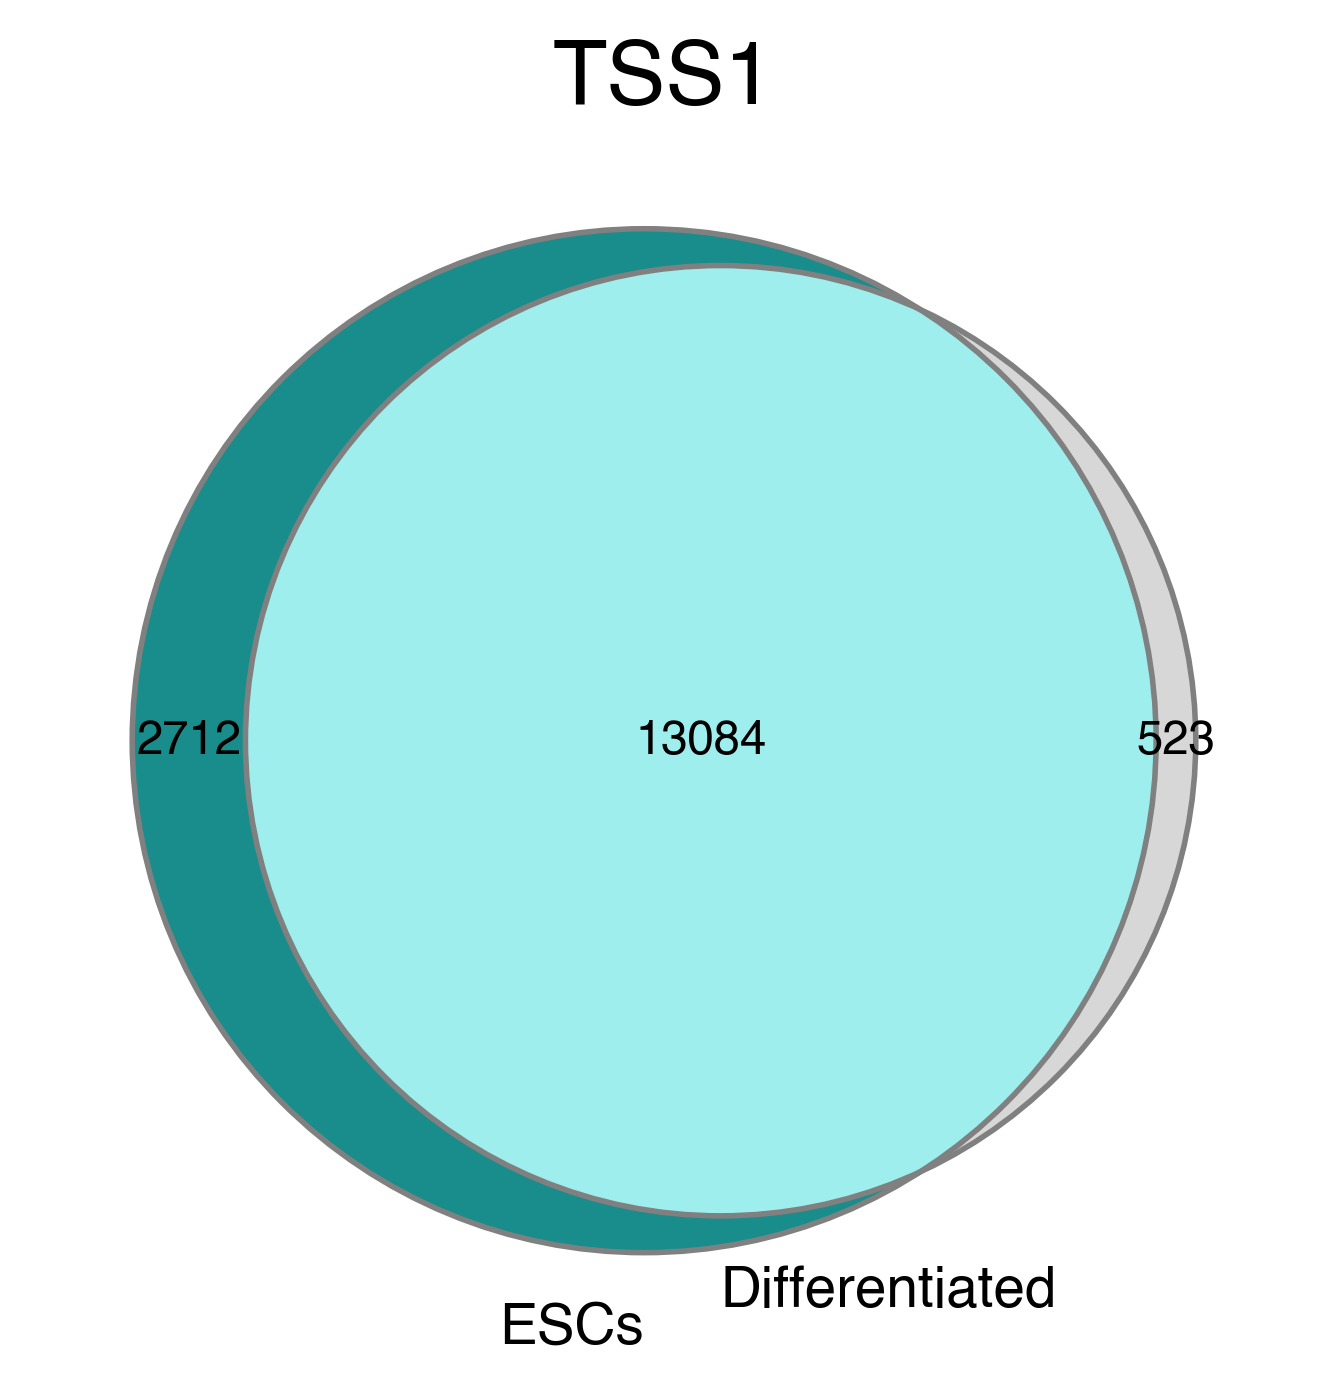

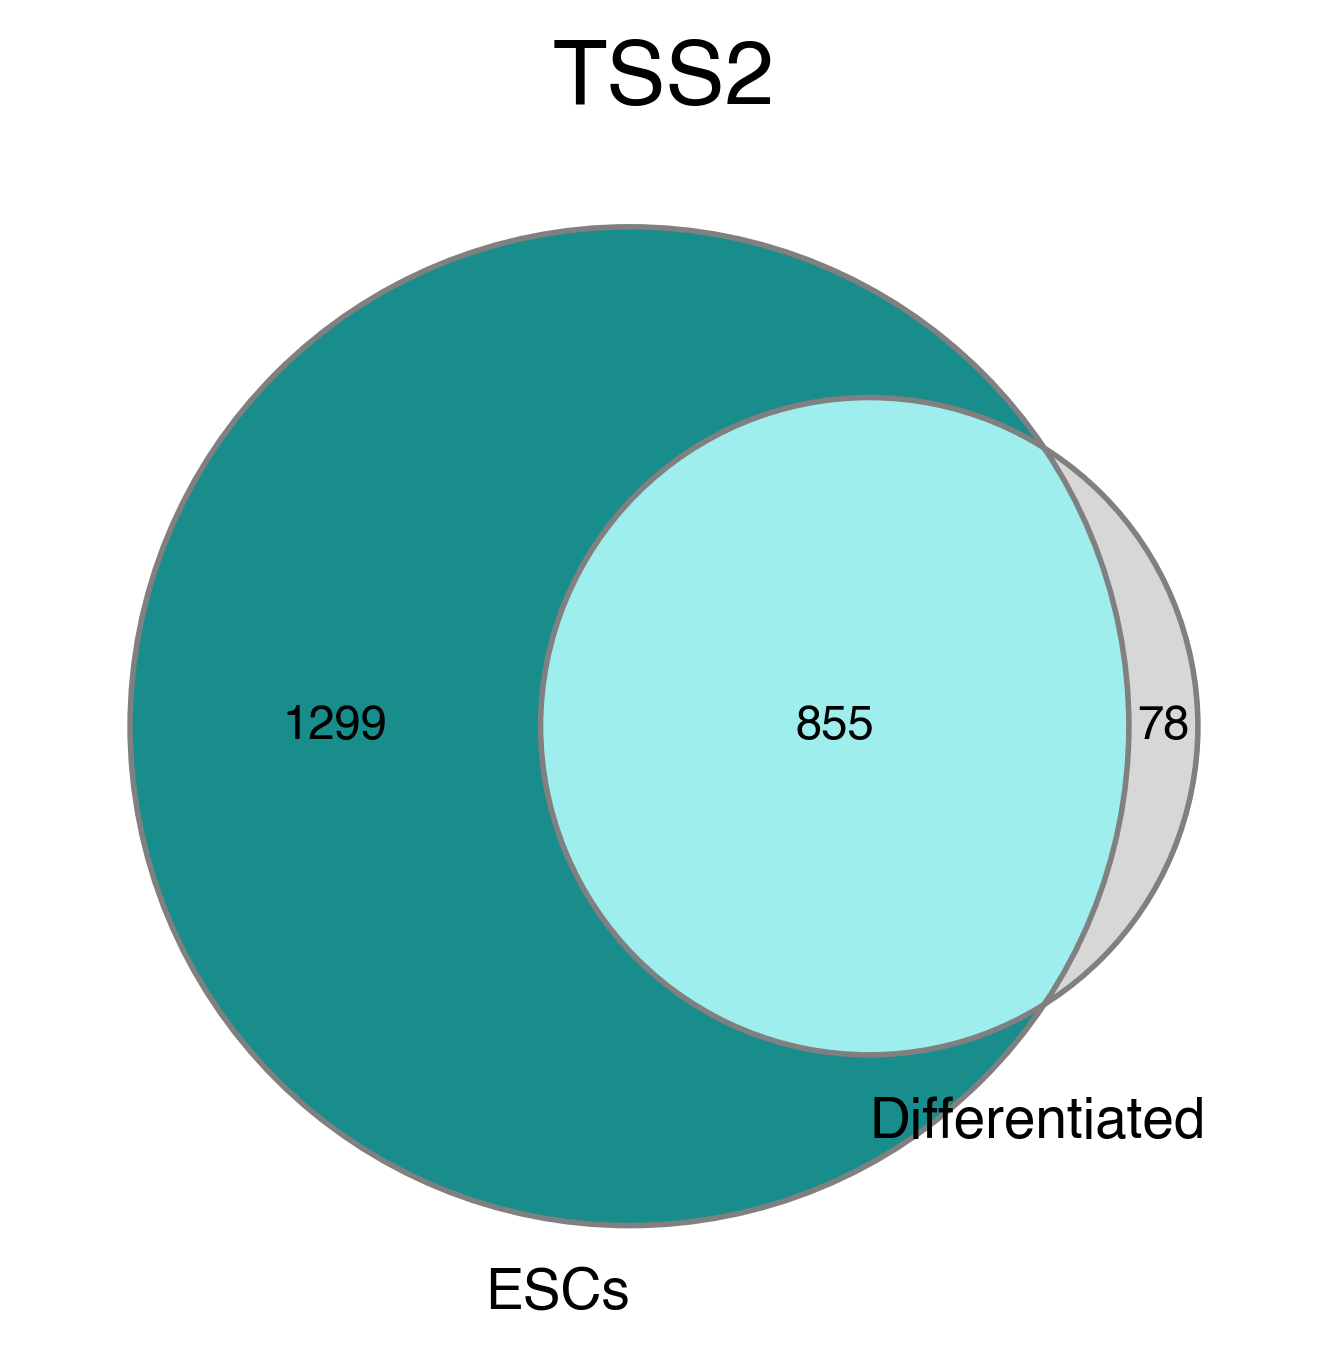

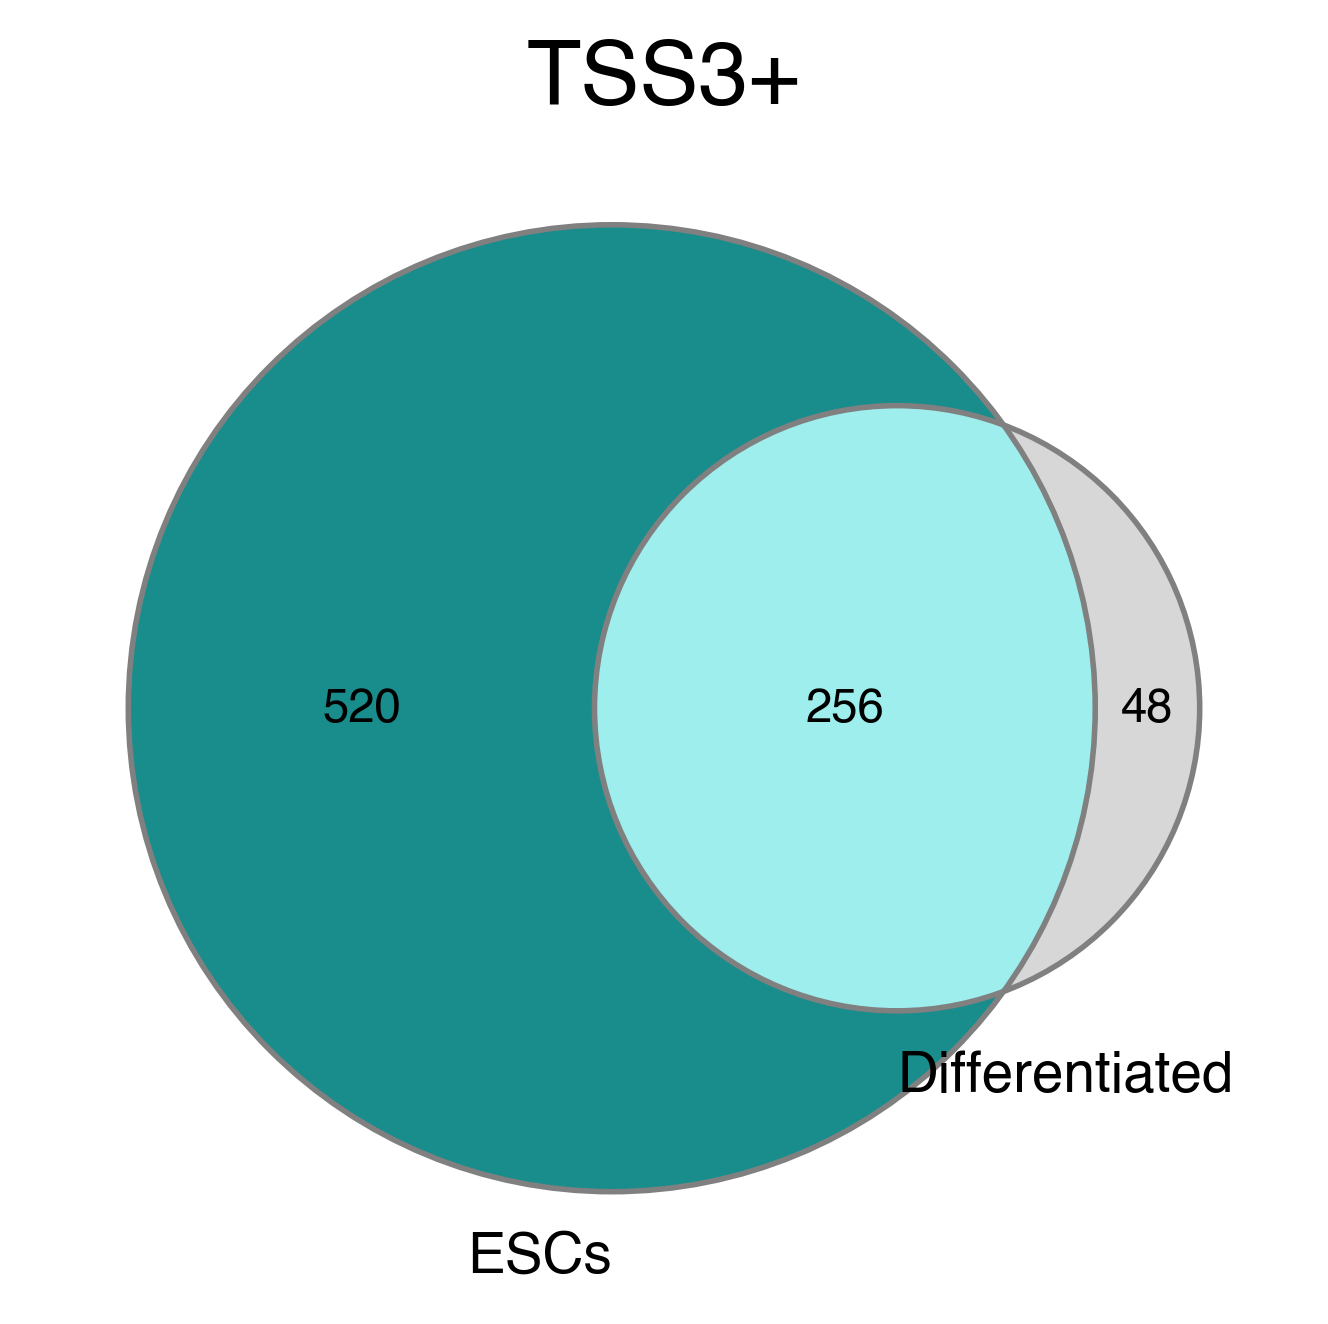

In [116]:

a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
#b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') | (prom_1['Lin'] == 'END') | (prom_1['Lin'] == 'MES') ] ['gene'].unique())


venn2([set(a),set(c)], set_labels = ('ESCs', 'Differentiated'),
      set_colors=['teal','lightgrey'], alpha = 0.9,)
venn2_circles([set(a),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
#b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') | (prom_2['Lin'] == 'END') | (prom_2['Lin'] == 'MES') ] ['gene'].unique())


venn2([set(a),set(c)], set_labels = ('ESCs', 'Differentiated'),
      set_colors=['teal','lightgrey'], alpha = 0.9,)
venn2_circles([set(a),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
#b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') | (prom_3['Lin'] == 'END') | (prom_3['Lin'] == 'MES') ] ['gene'].unique())


venn2([set(a),set(c)], set_labels = ('ESCs', 'Differentiated'),
      set_colors=['teal','lightgrey'], alpha = 0.9,)
venn2_circles([set(a),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



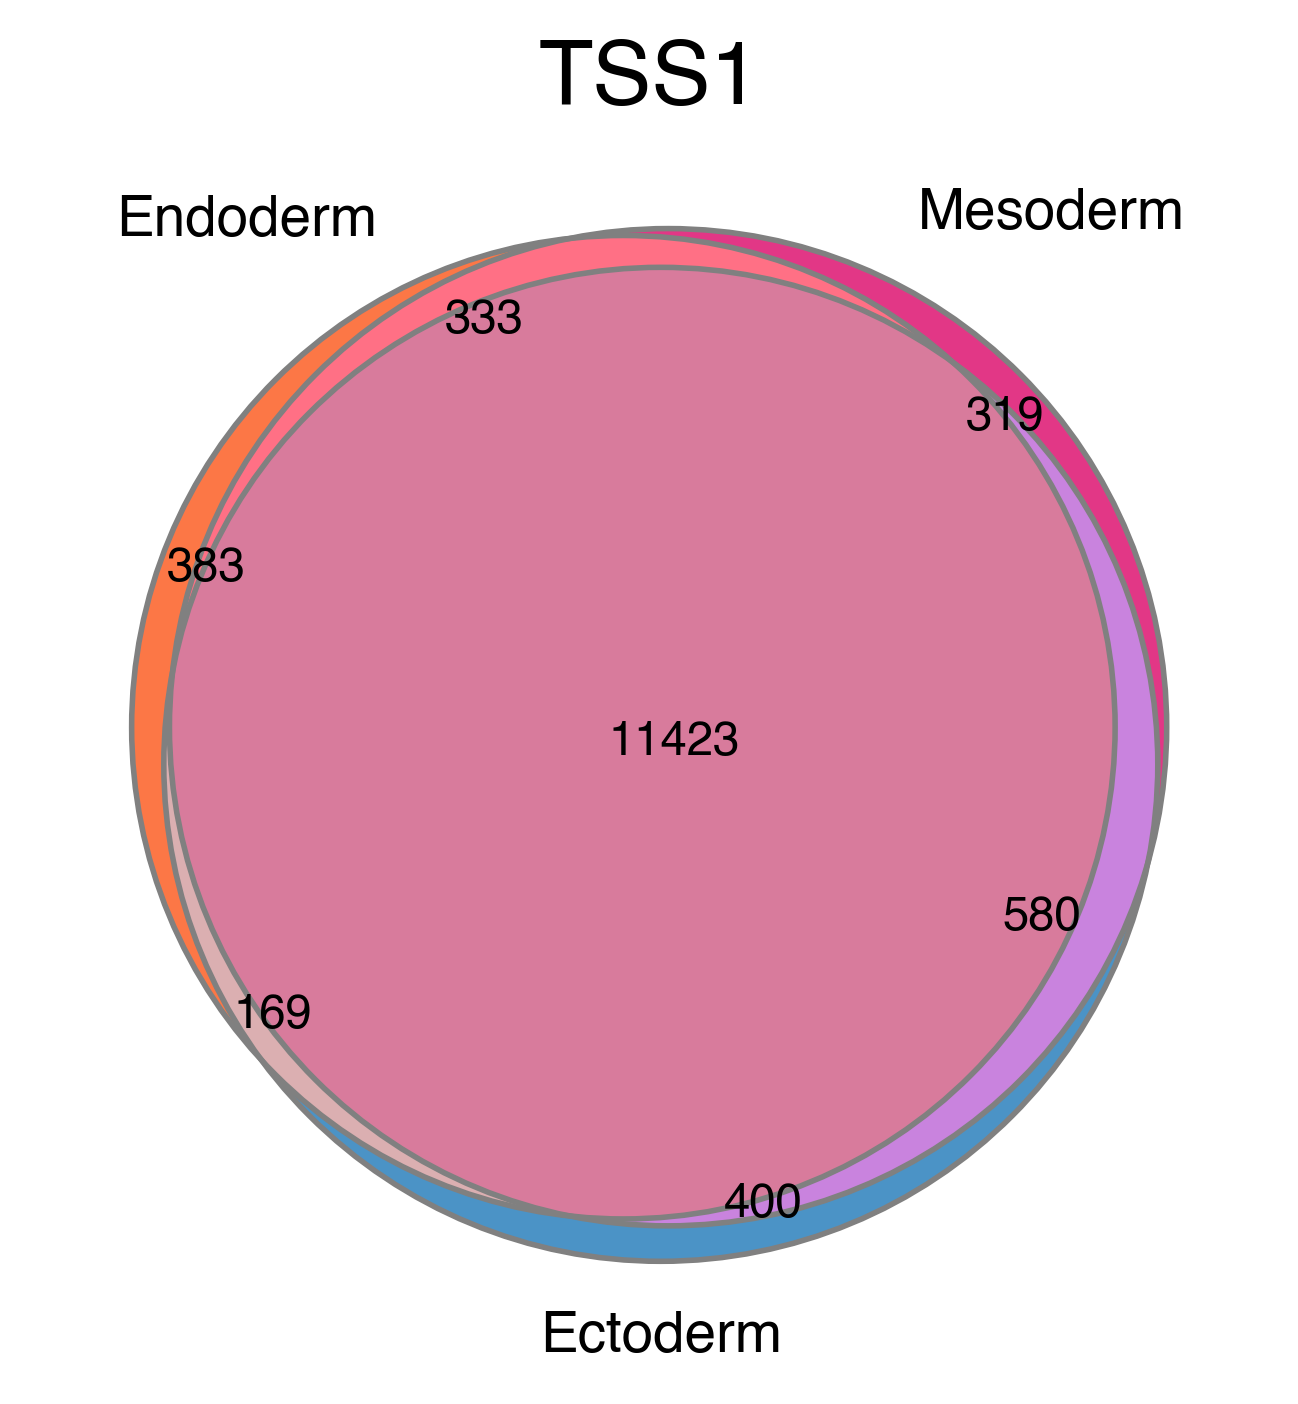

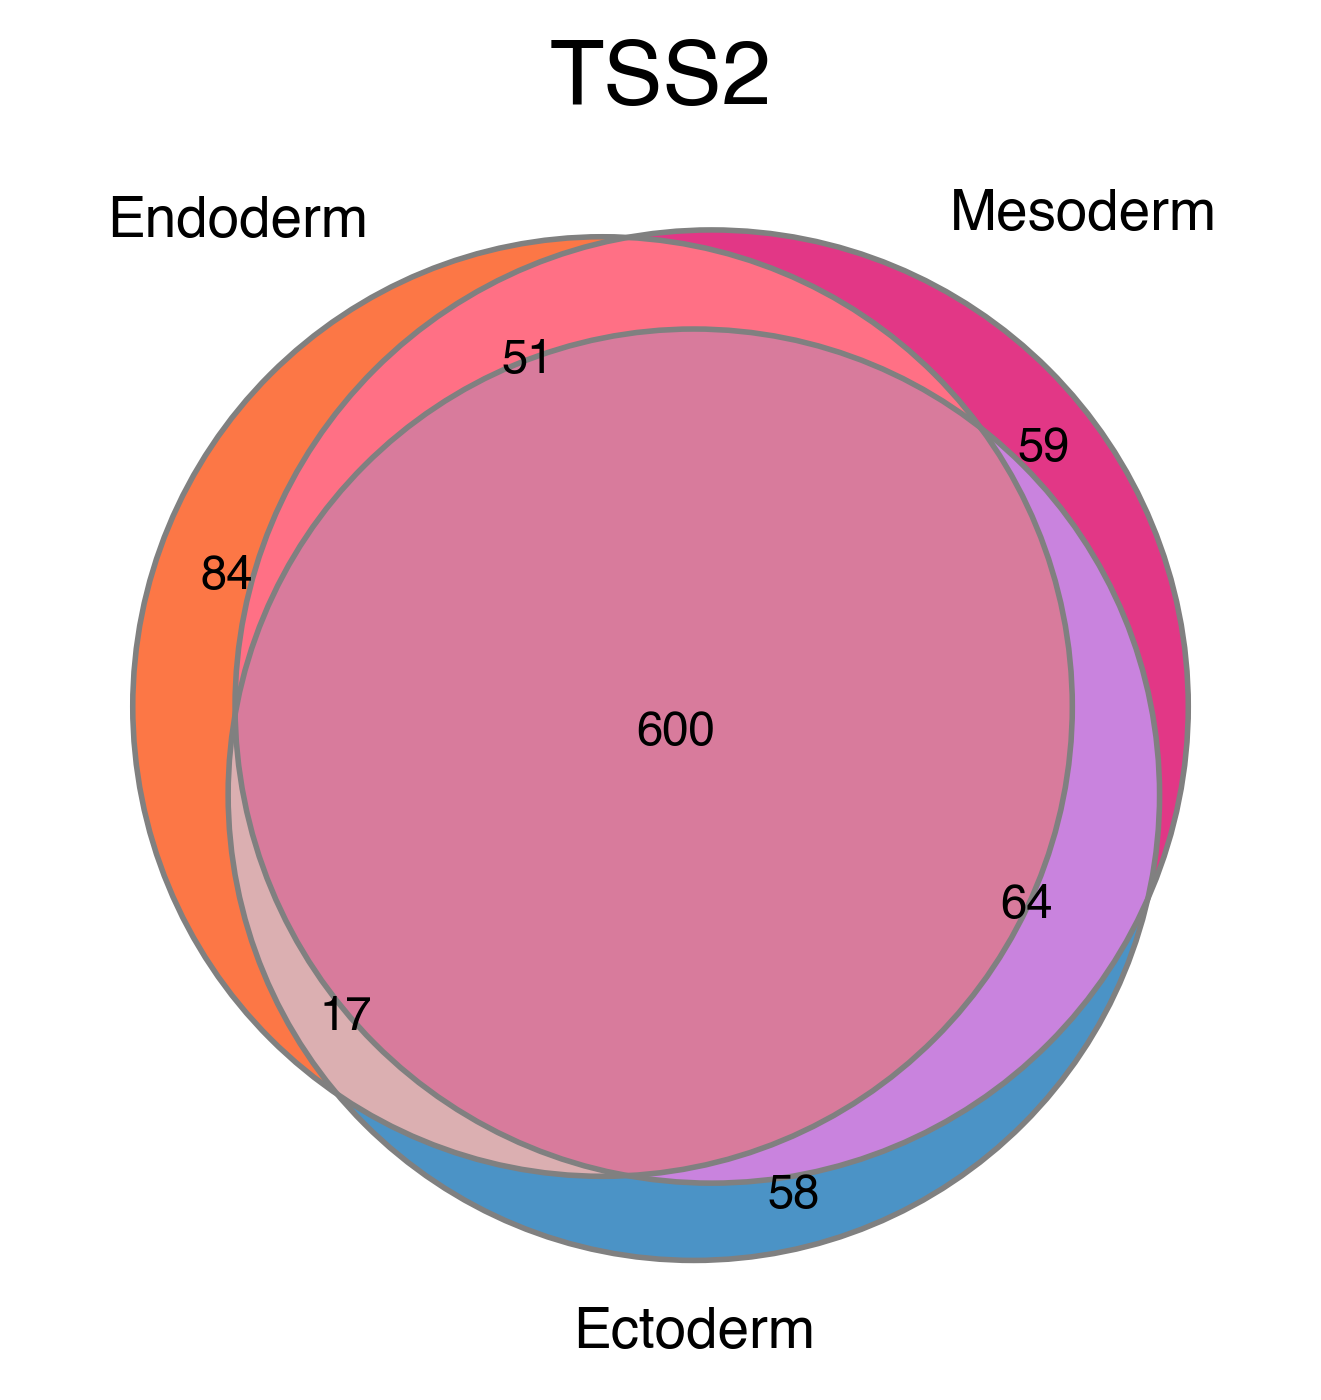

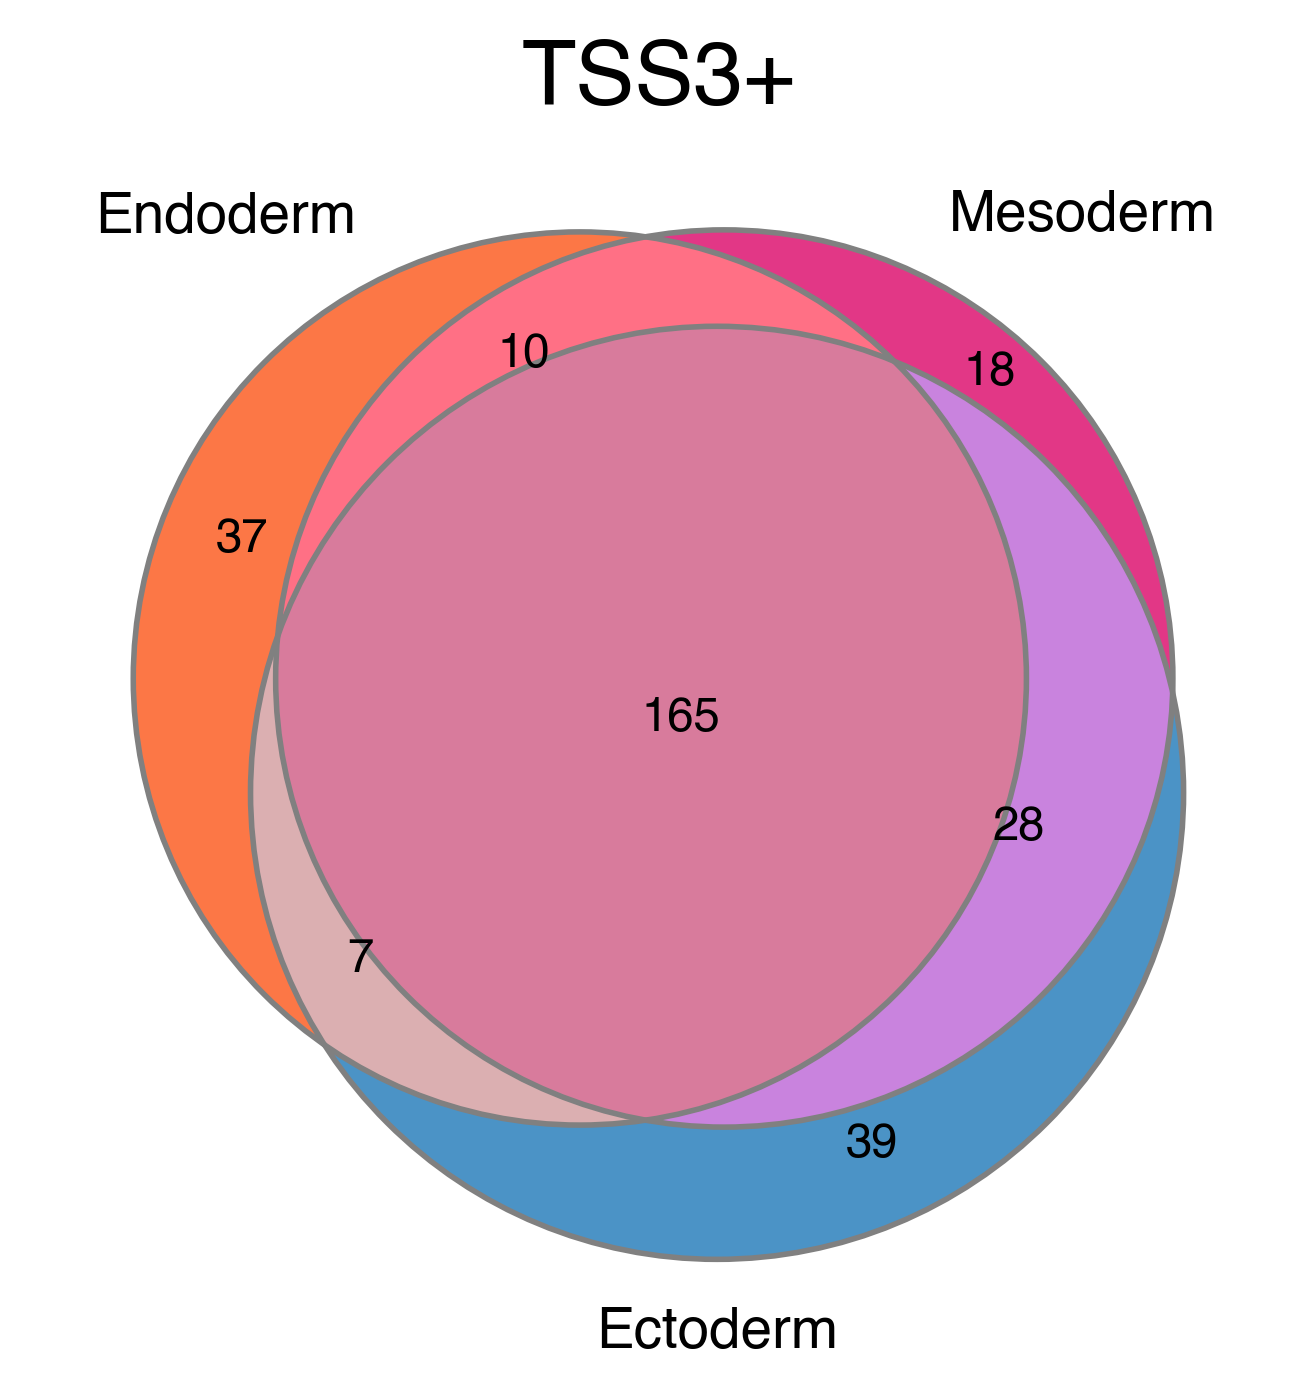

In [113]:

a = list(prom_1[(prom_1['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'MES') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())



venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'MES') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'MES') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



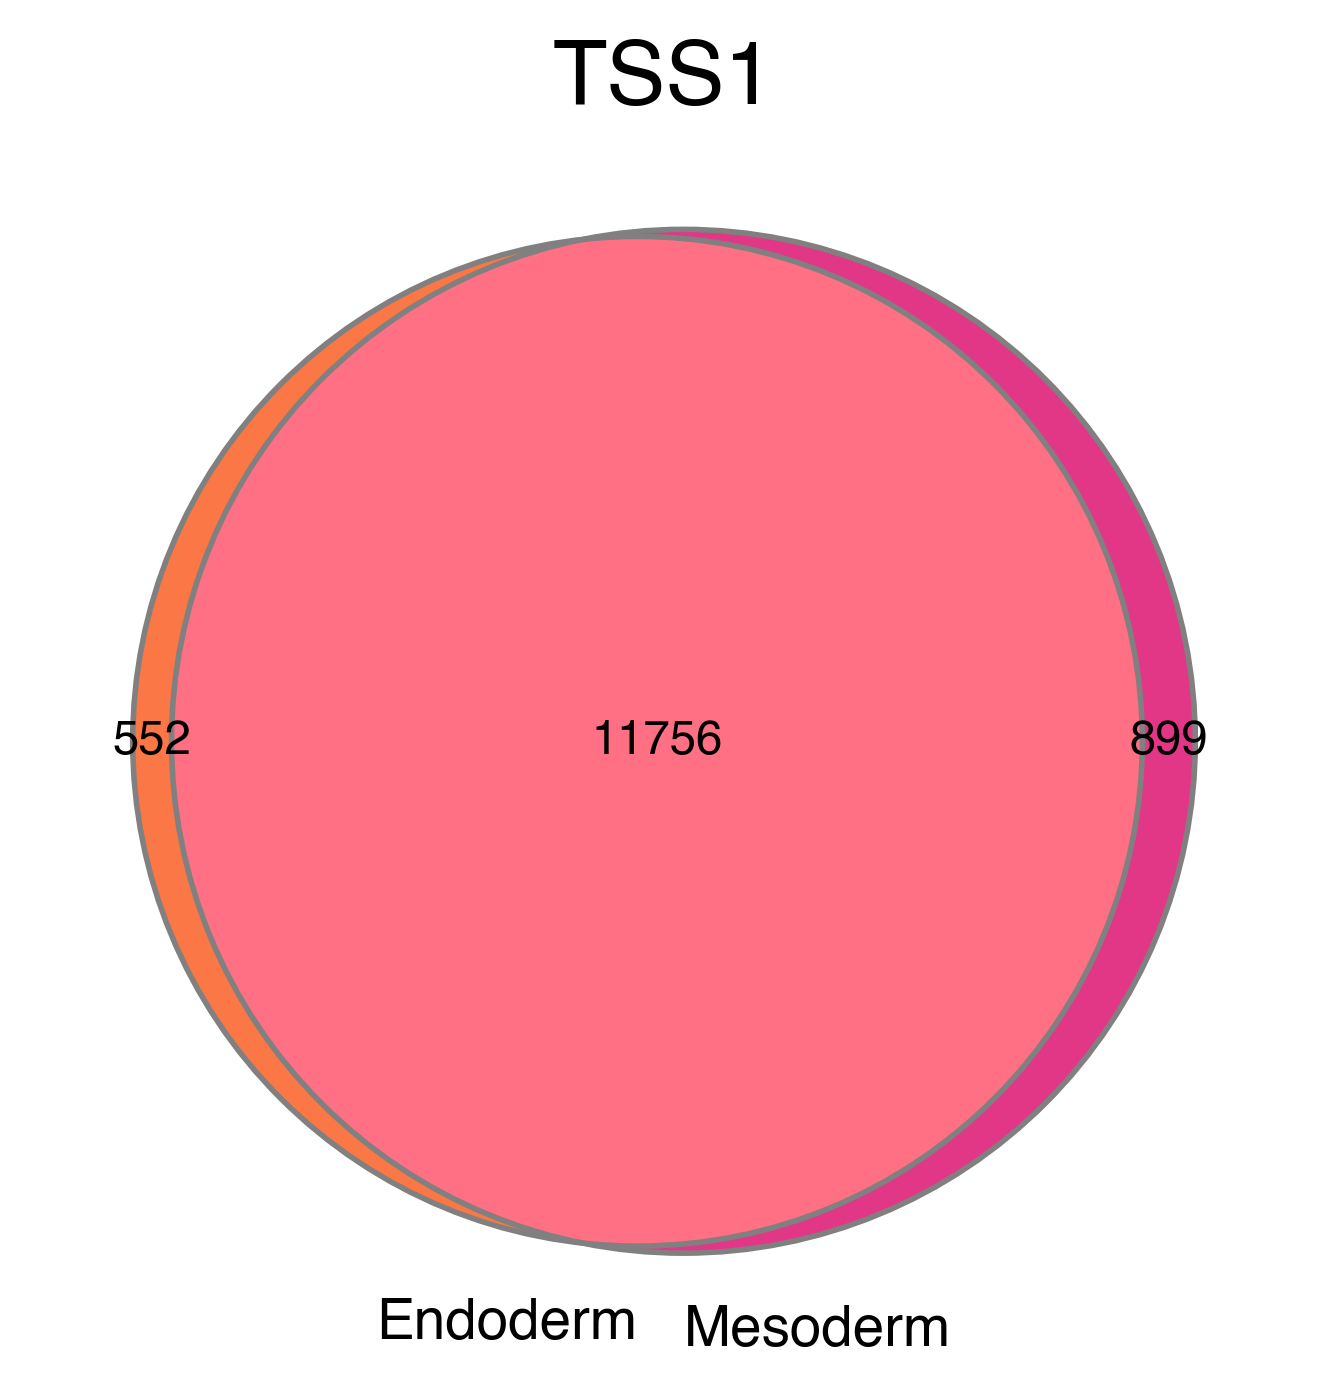

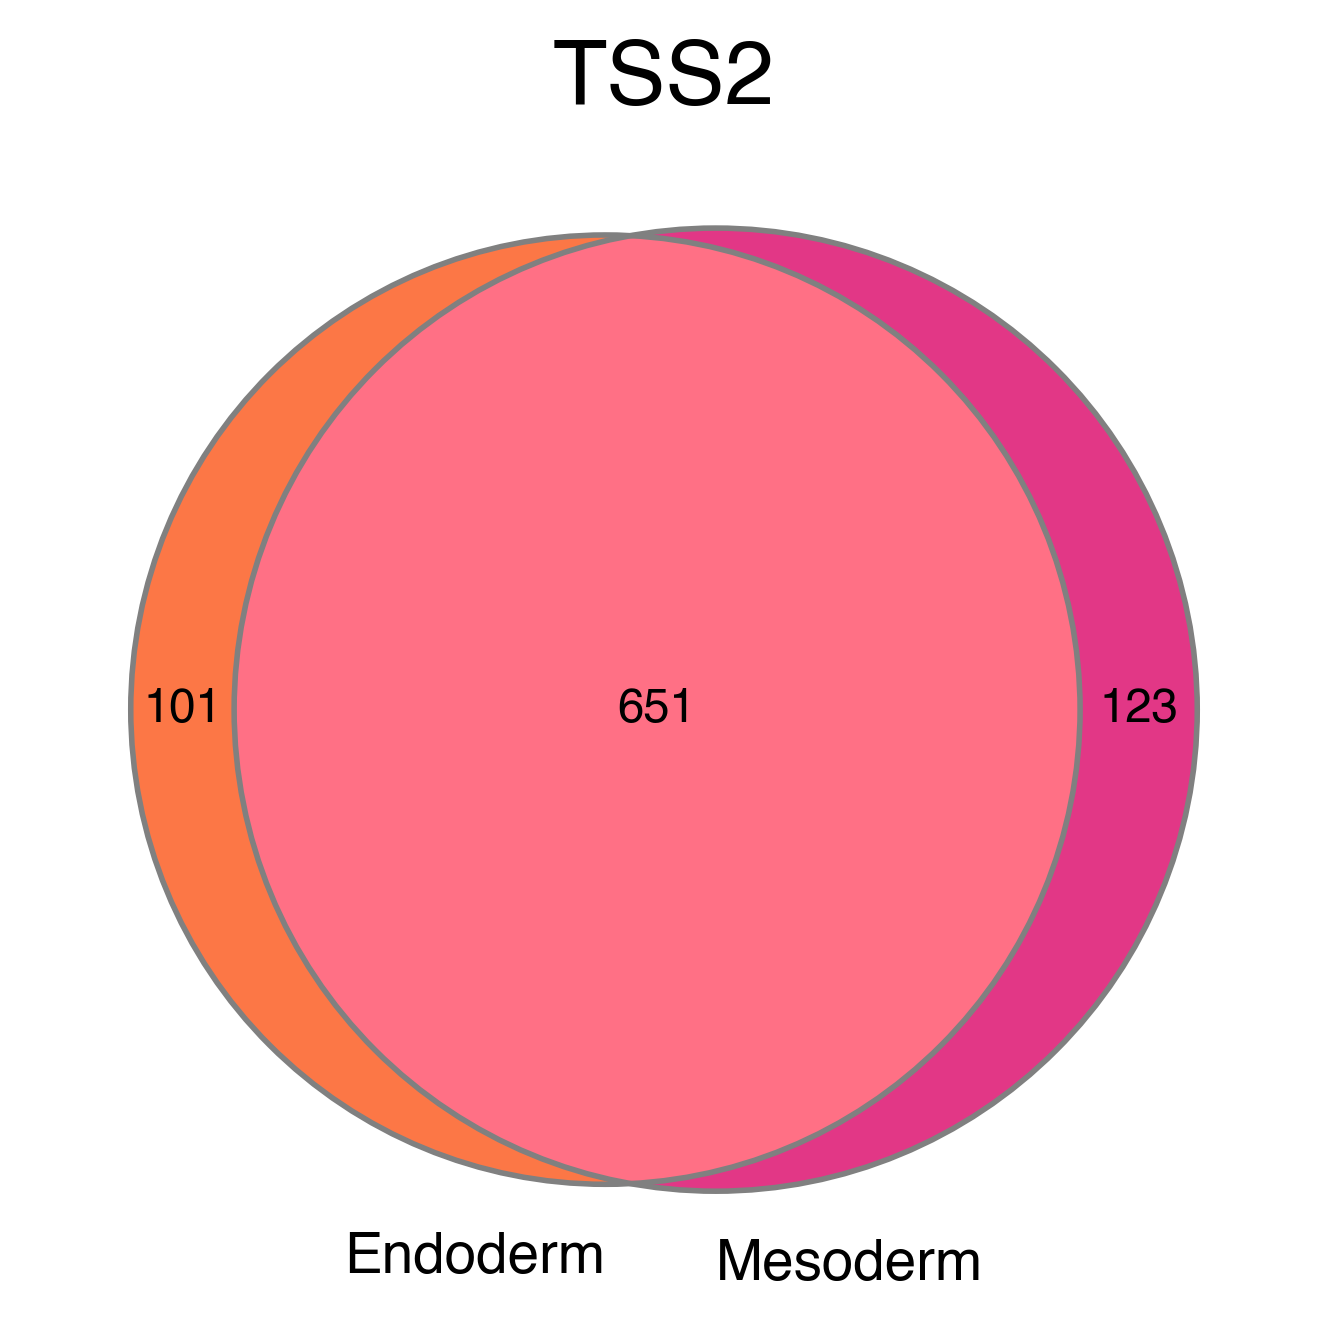

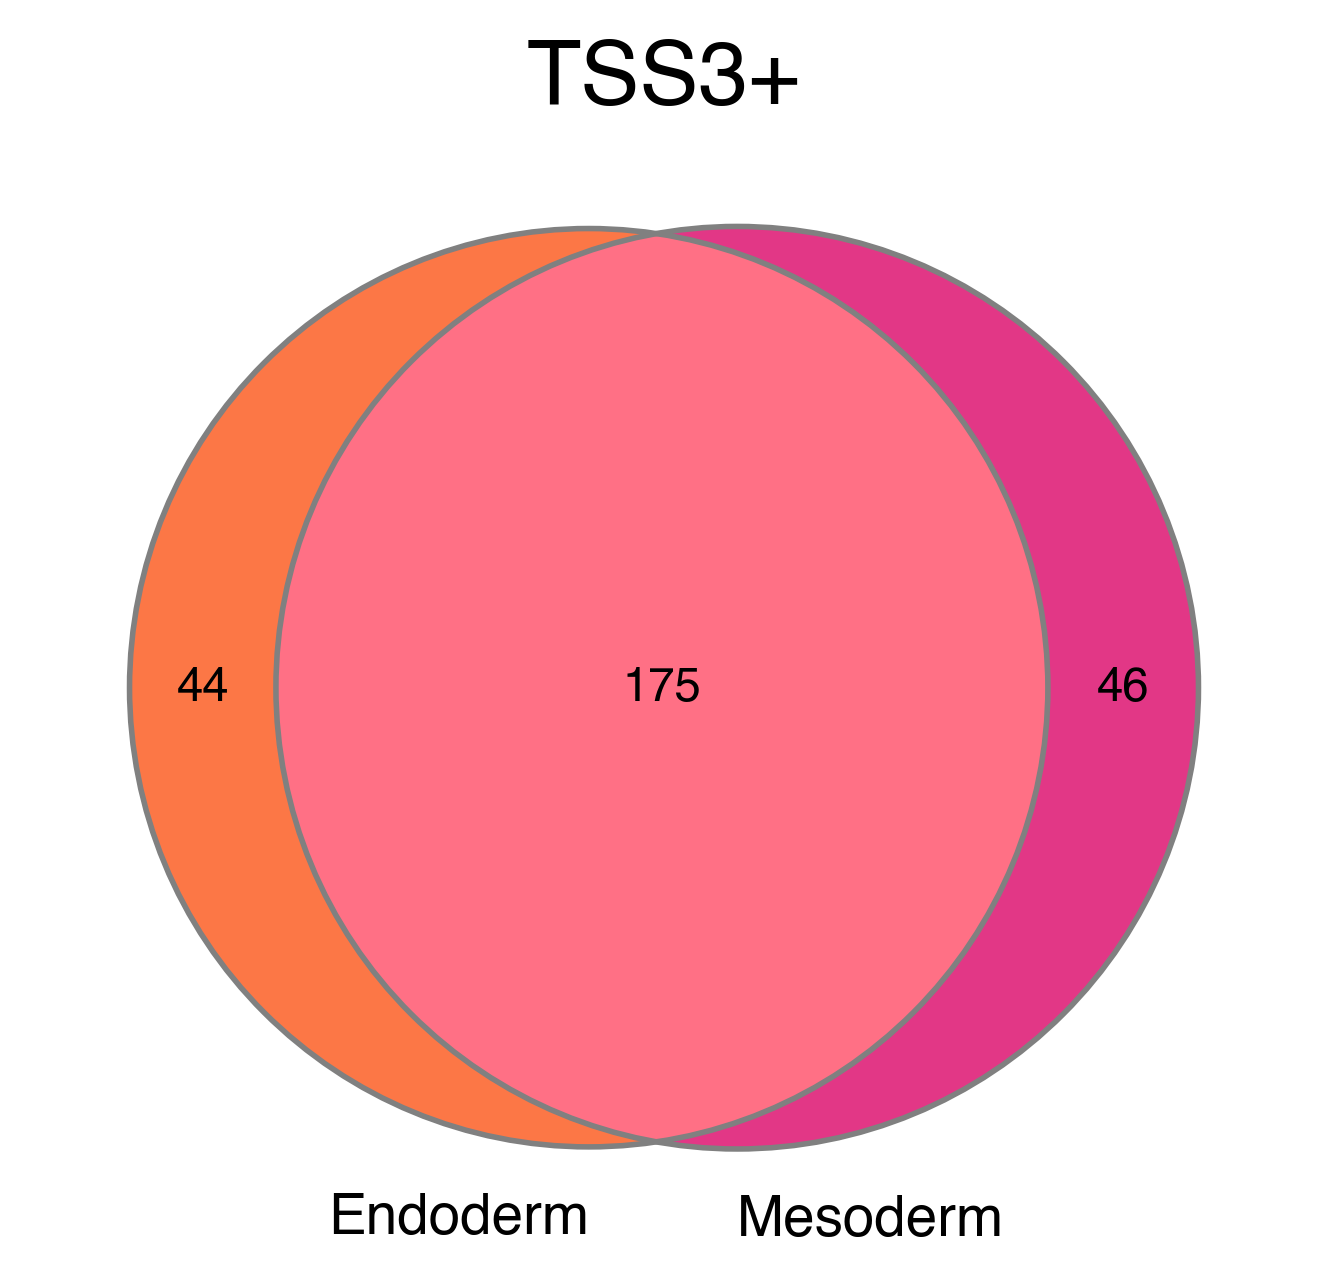

In [114]:

a = list(prom_1[(prom_1['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'MES') ] ['gene'].unique())
#c = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())



venn2([set(a),set(b)], set_labels = ('Endoderm','Mesoderm'),
      set_colors=[ '#fc6832', '#df2179'], alpha = 0.9,)
venn2_circles([set(a),set(b)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'MES') ] ['gene'].unique())
#c = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())


venn2([set(a),set(b)], set_labels = ('Endoderm','Mesoderm'),
      set_colors=[ '#fc6832', '#df2179'], alpha = 0.9,)
venn2_circles([set(a),set(b)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'MES') ] ['gene'].unique())
#c = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())


venn2([set(a),set(b)], set_labels = ('Endoderm','Mesoderm'),
      set_colors=[ '#fc6832', '#df2179'], alpha = 0.9,)
venn2_circles([set(a),set(b)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



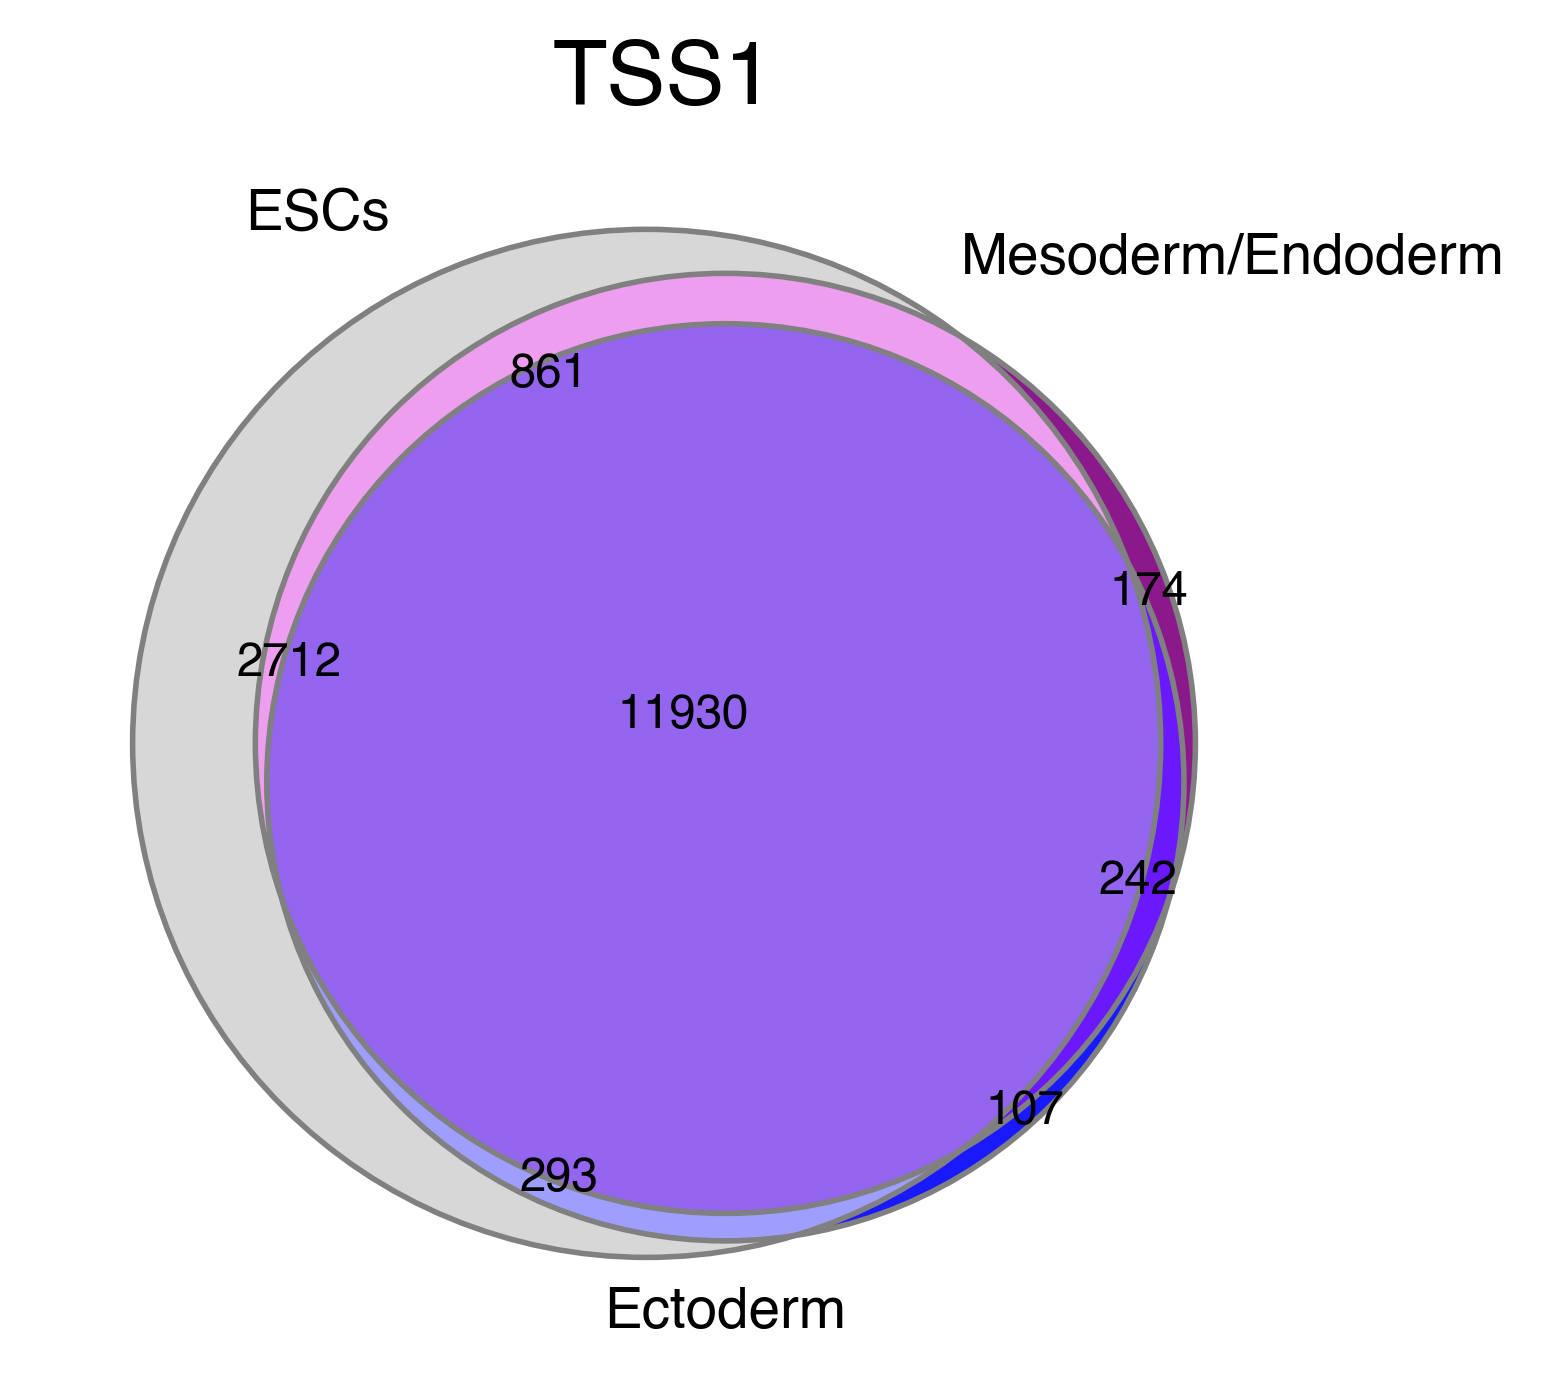

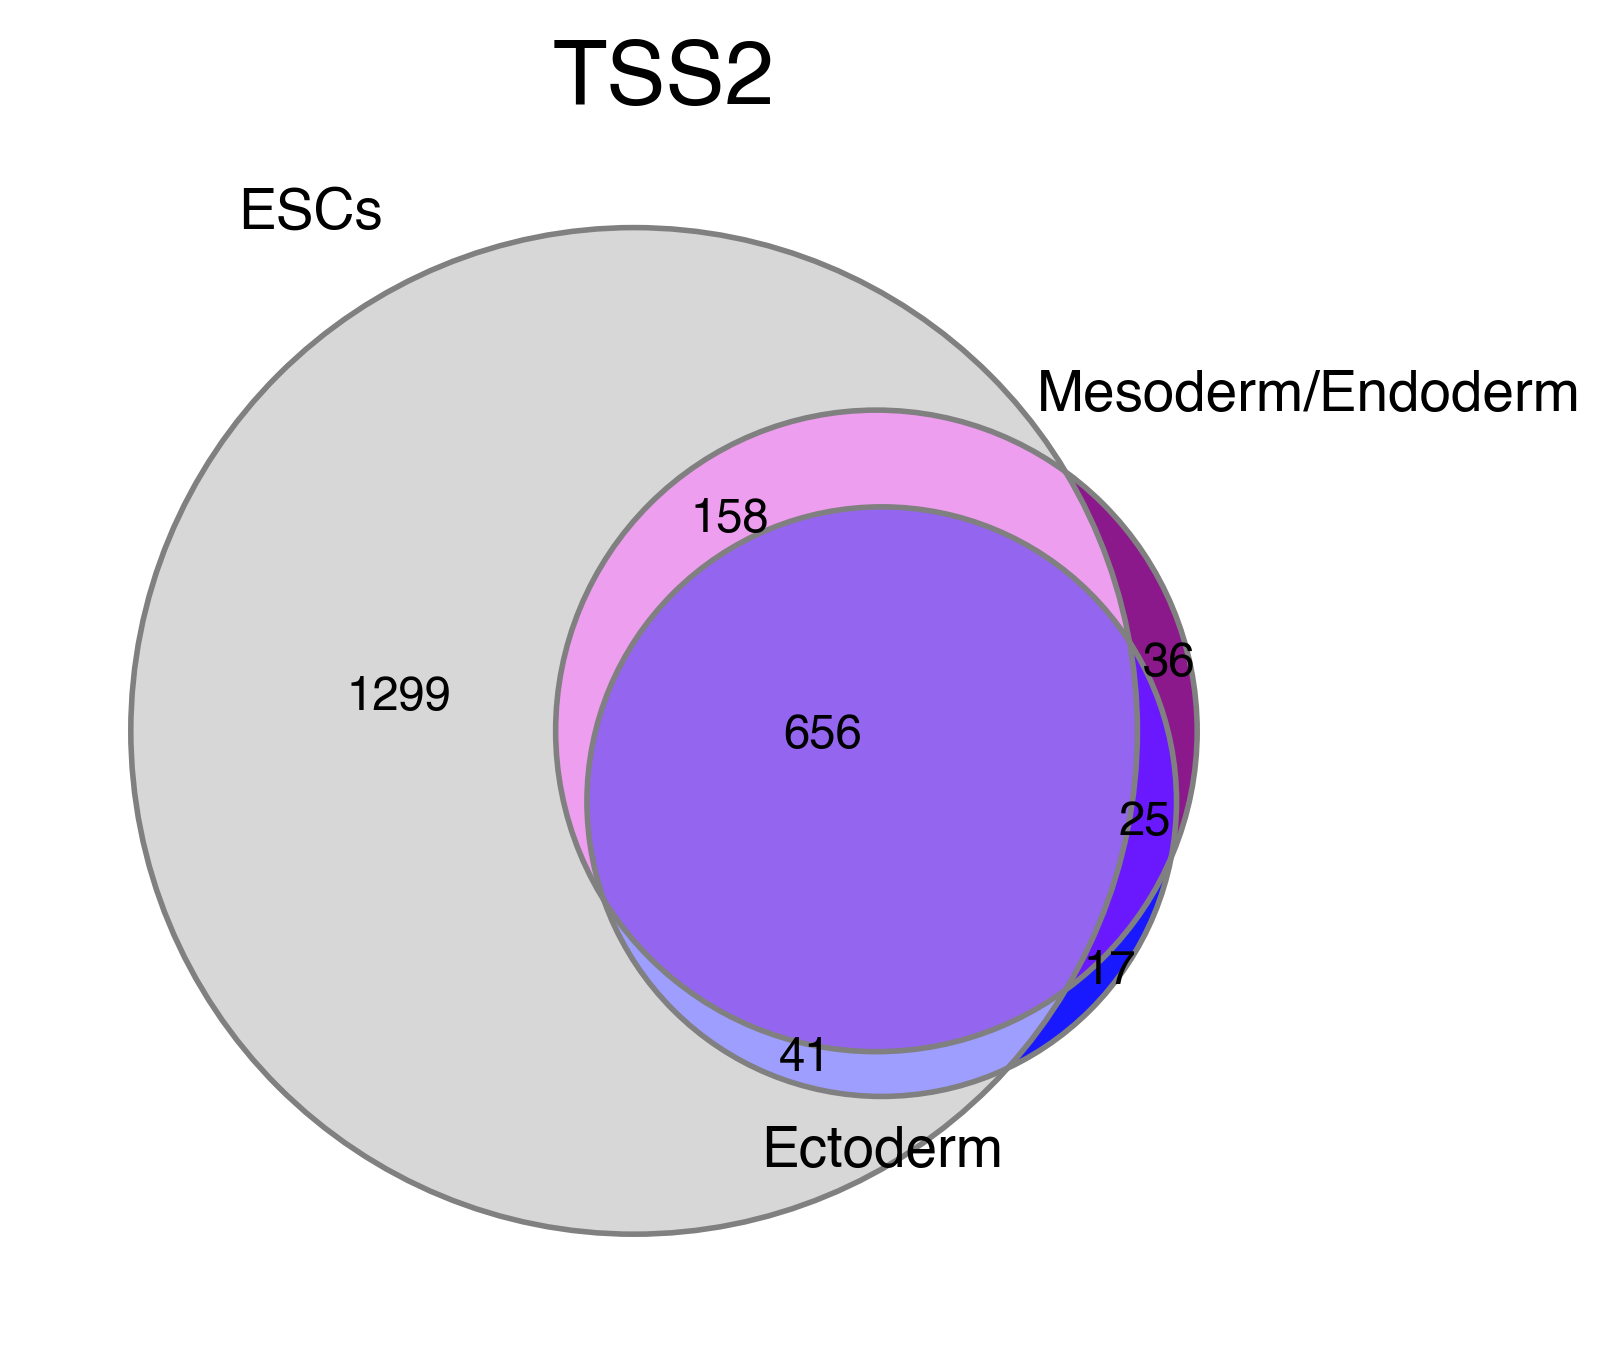

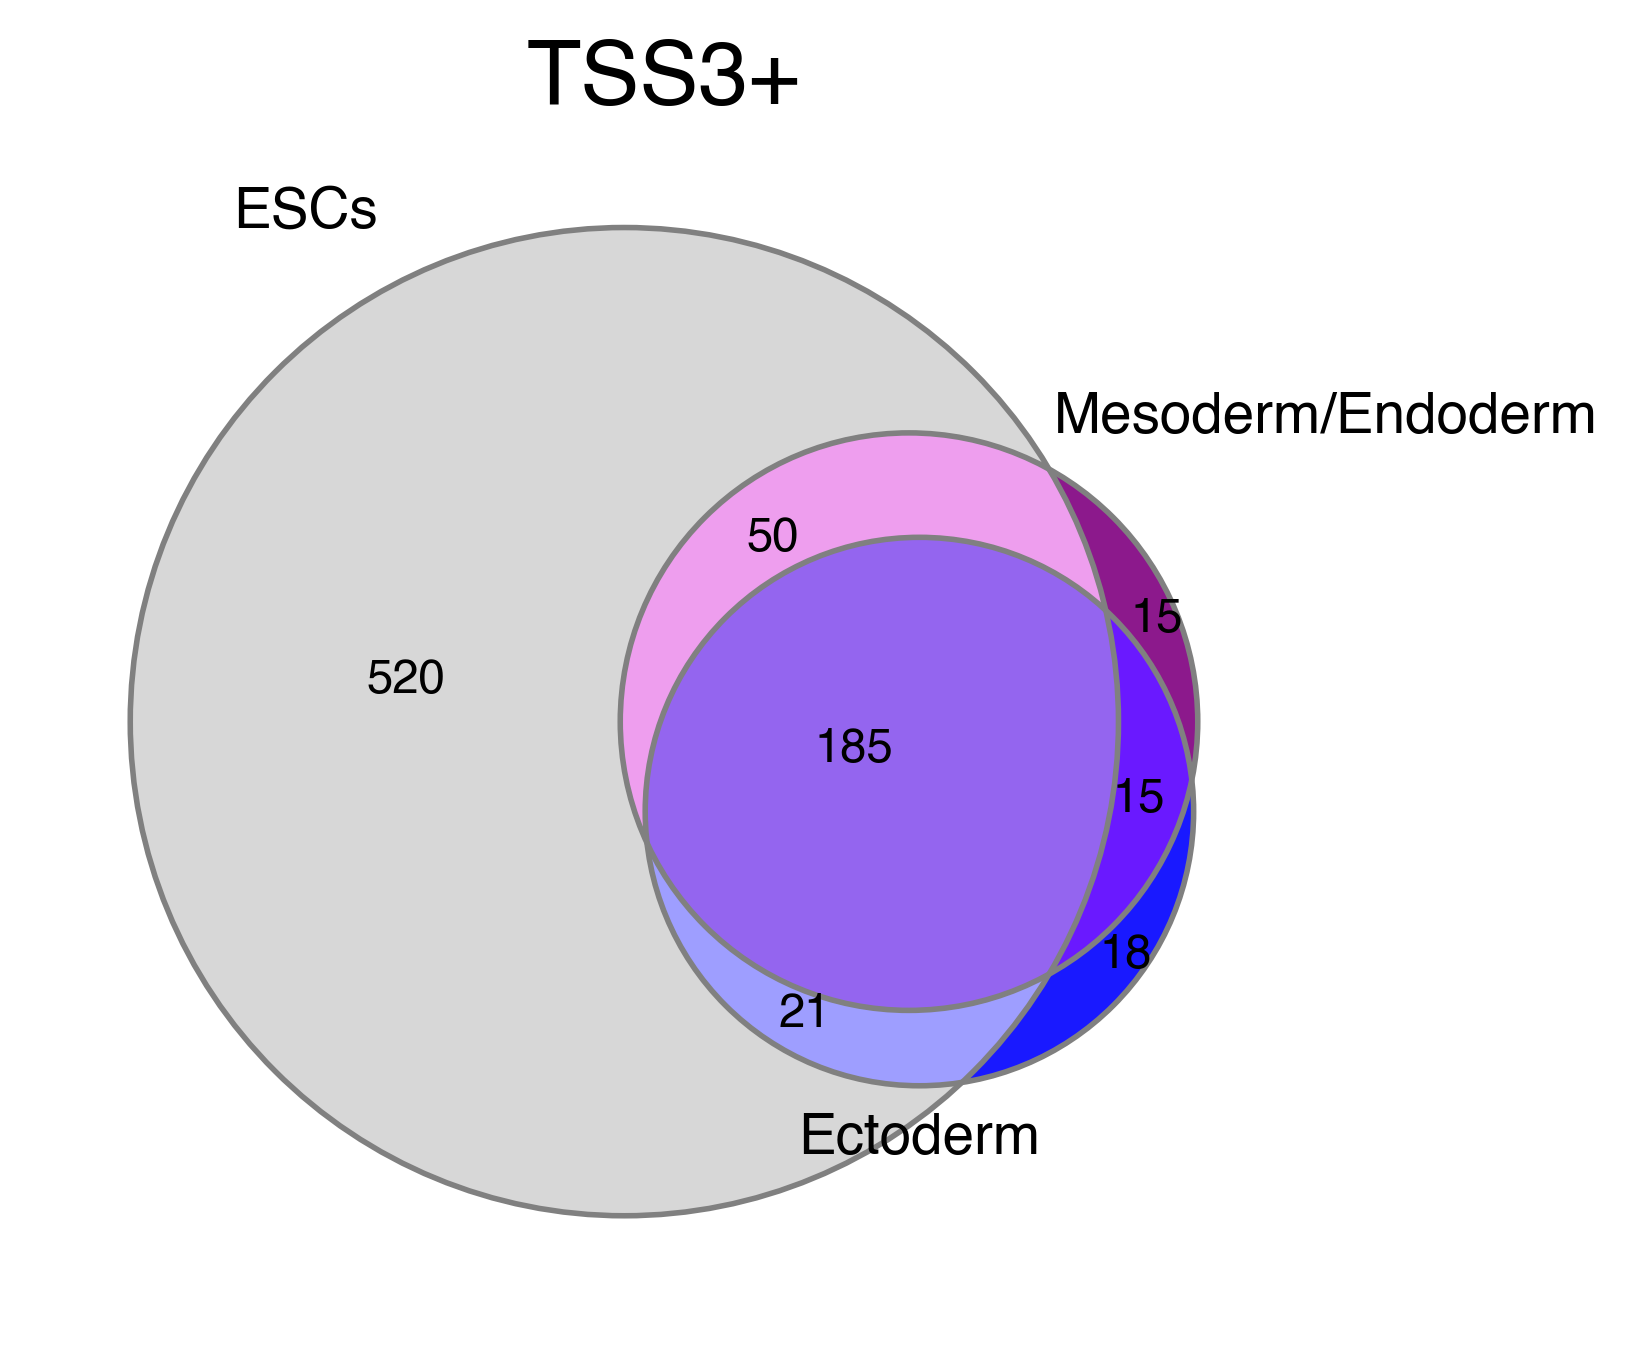

In [103]:

a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'MES') | (prom_1['Lin'] == 'END') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESCs','Mesoderm/Endoderm', 'Ectoderm'),
      set_colors=['lightgrey','purple','blue'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'MES') | (prom_2['Lin'] == 'END') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESCs','Mesoderm/Endoderm', 'Ectoderm'),
      set_colors=['lightgrey','purple','blue'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'MES') | (prom_3['Lin'] == 'END') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())

               
                
venn3([set(a),set(b),set(c)], set_labels = ('ESCs','Mesoderm/Endoderm', 'Ectoderm'),
      set_colors=['lightgrey','purple','blue'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



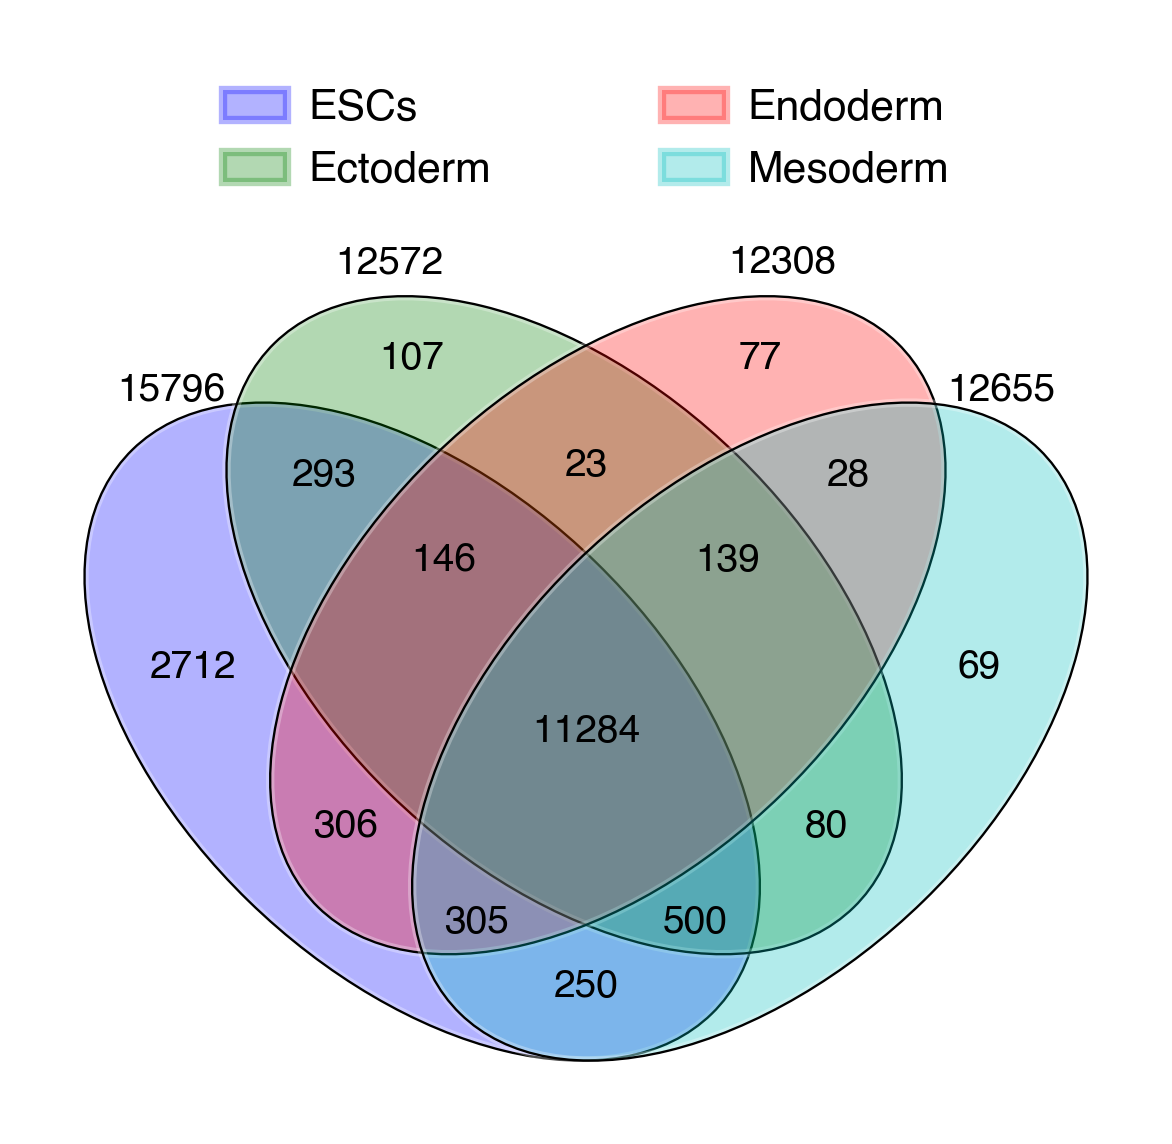

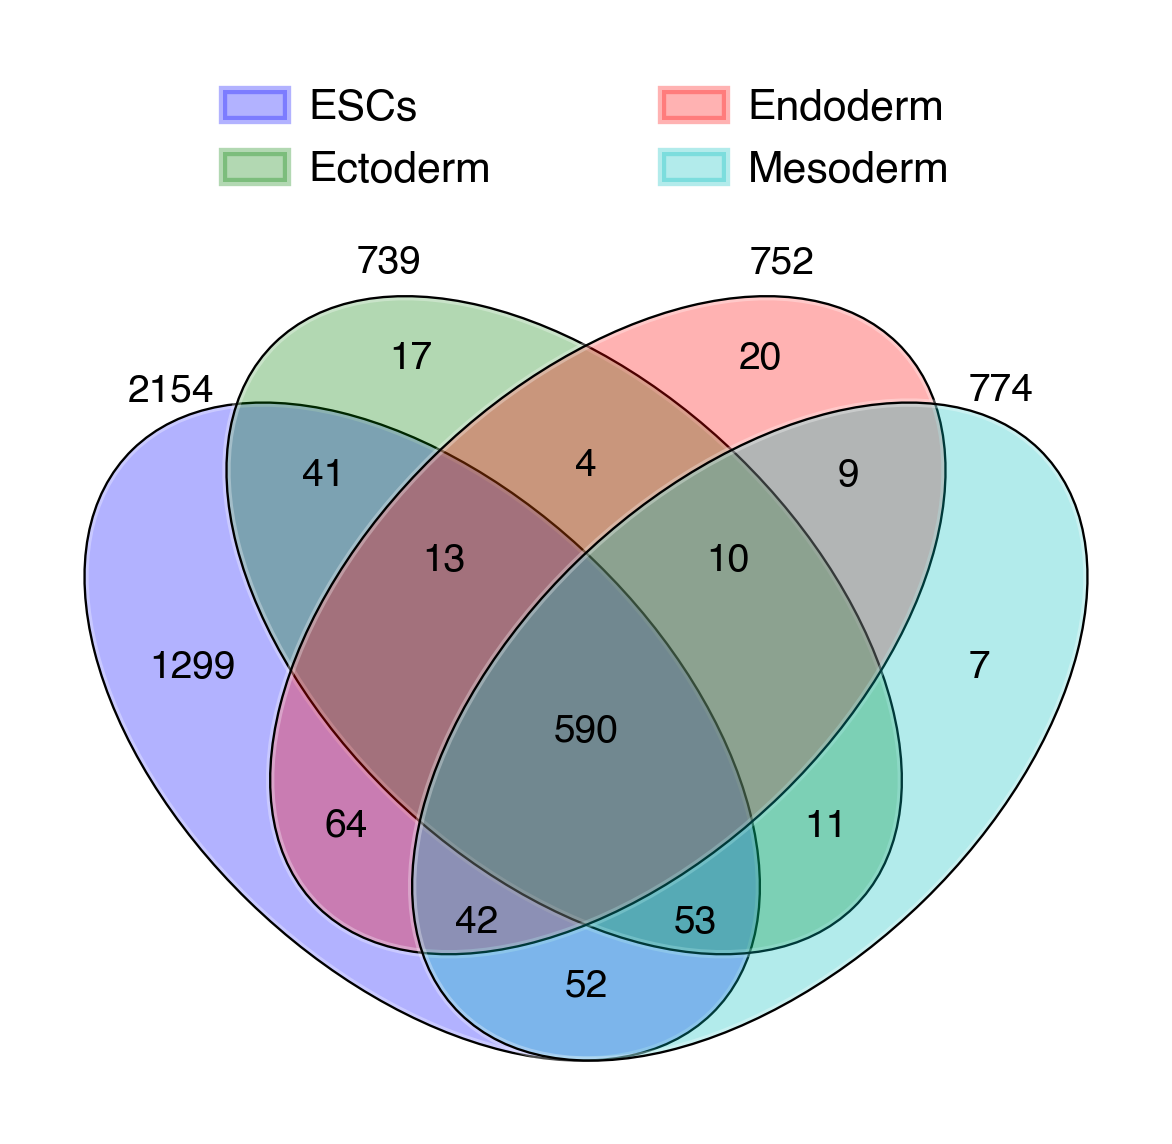

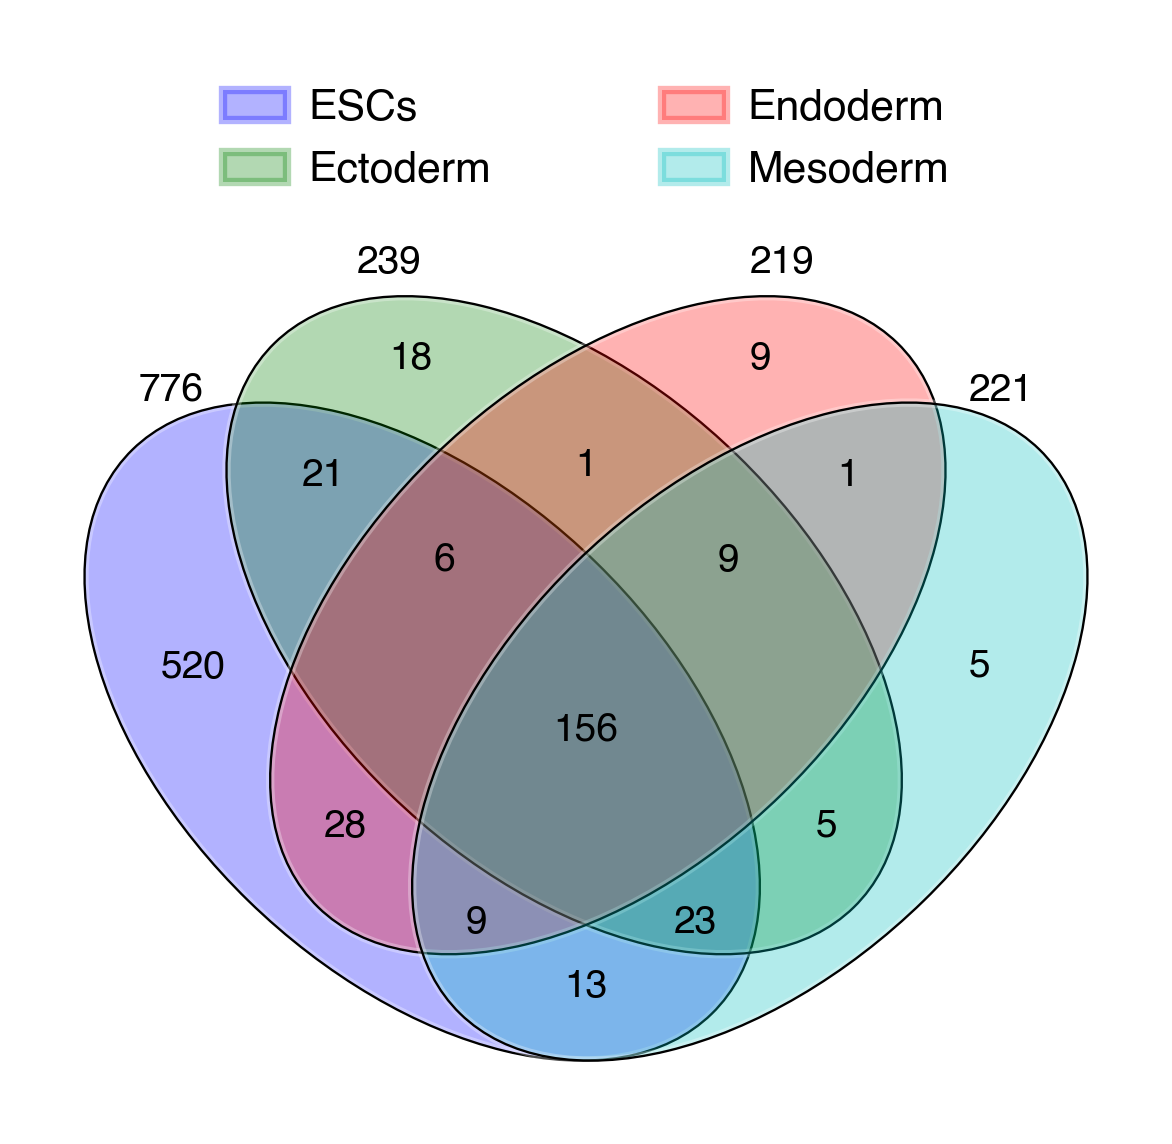

In [112]:
from venny4py.venny4py import *

#dict of sets

a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'END') ] ['gene'].unique())
d = list(prom_1[(prom_1['Lin'] == 'MES') ] ['gene'].unique())


sets = {
    'ESCs': set(a),
    'Ectoderm': set(b),
    'Endoderm': set(c),
    'Mesoderm': set(d)}
    
venny4py(sets=sets,)
plt.show()

a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'END') ] ['gene'].unique())
d = list(prom_2[(prom_2['Lin'] == 'MES') ] ['gene'].unique())


sets = {
    'ESCs': set(a),
    'Ectoderm': set(b),
    'Endoderm': set(c),
    'Mesoderm': set(d)}
    
venny4py(sets=sets,)
plt.show()

a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'END') ] ['gene'].unique())
d = list(prom_3[(prom_3['Lin'] == 'MES') ] ['gene'].unique())


sets = {
    'ESCs': set(a),
    'Ectoderm': set(b),
    'Endoderm': set(c),
    'Mesoderm': set(d)}
    
venny4py(sets=sets,)
plt.show()

In [117]:
import scanpy as sc

In [123]:
test_genes = ['Dlgap1', 'Ank3', 'Tacc2', 'Epb41l3', 'Aopep', 'Tsc22d1', 'Robo1',
       'Adgrb1', 'Nav2', 'Rbpj', 'Aff1', 'Mapt', 'Tenm4', 'Nr4a1',
       'Rab37', 'Wscd2', 'Pde4d', 'Dmd', 'Tnrc6b', 'Zfp516', 'Shroom3',
       'Adgrg1', 'Myo10', 'Zmiz1', 'Sgk1', 'Dlgap4', 'Kat6b', 'Dnah8',
       'Adgra2', 'Syngap1', 'Nmnat2', 'Aim2', 'Frmd4a', 'Arhgap6',
       'Ildr1', 'Jade1', 'Arhgap22', 'Palld', 'Baz2b', 'Hk1', 'Agtpbp1',
       'Arid5b', 'Stox2', 'Phldb2', 'Slc39a10', 'Bicral', 'Trim2', 'Nfib',
       'Pole4', 'Tns1', 'Rap1gap2', 'Slc25a12', 'Csnk1e', 'Gab1',
       'Amotl1', 'Dlc1', 'Fam178b', 'Mcc', 'Gramd1b', 'Mecom', 'Wdtc1',
       'Mttp', 'Rnf220', 'Adipor2', 'Rbfox3', 'Cacna1c', 'Fbxl2', 'Kifc3',
       'Foxp1', 'Zfp217', 'Lima1', 'Rabgap1l']



allgenes = list(venn_diagram['gene'].unique())

In [124]:
def makeGO(genes, background = allgenes, num = 10, figsize = (4,2)):
    go = sc.queries.enrich({'cluster':genes,'all':background}, org="mmusculus")

    plotcl = go
    cluster = 'cluster'

    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == 'GO:BP'].sort_values(by='p_value')[['name','p_value']][0:num]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = figsize)
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], color = 'grey')
    ax.set_ylabel('')
    plt.show()

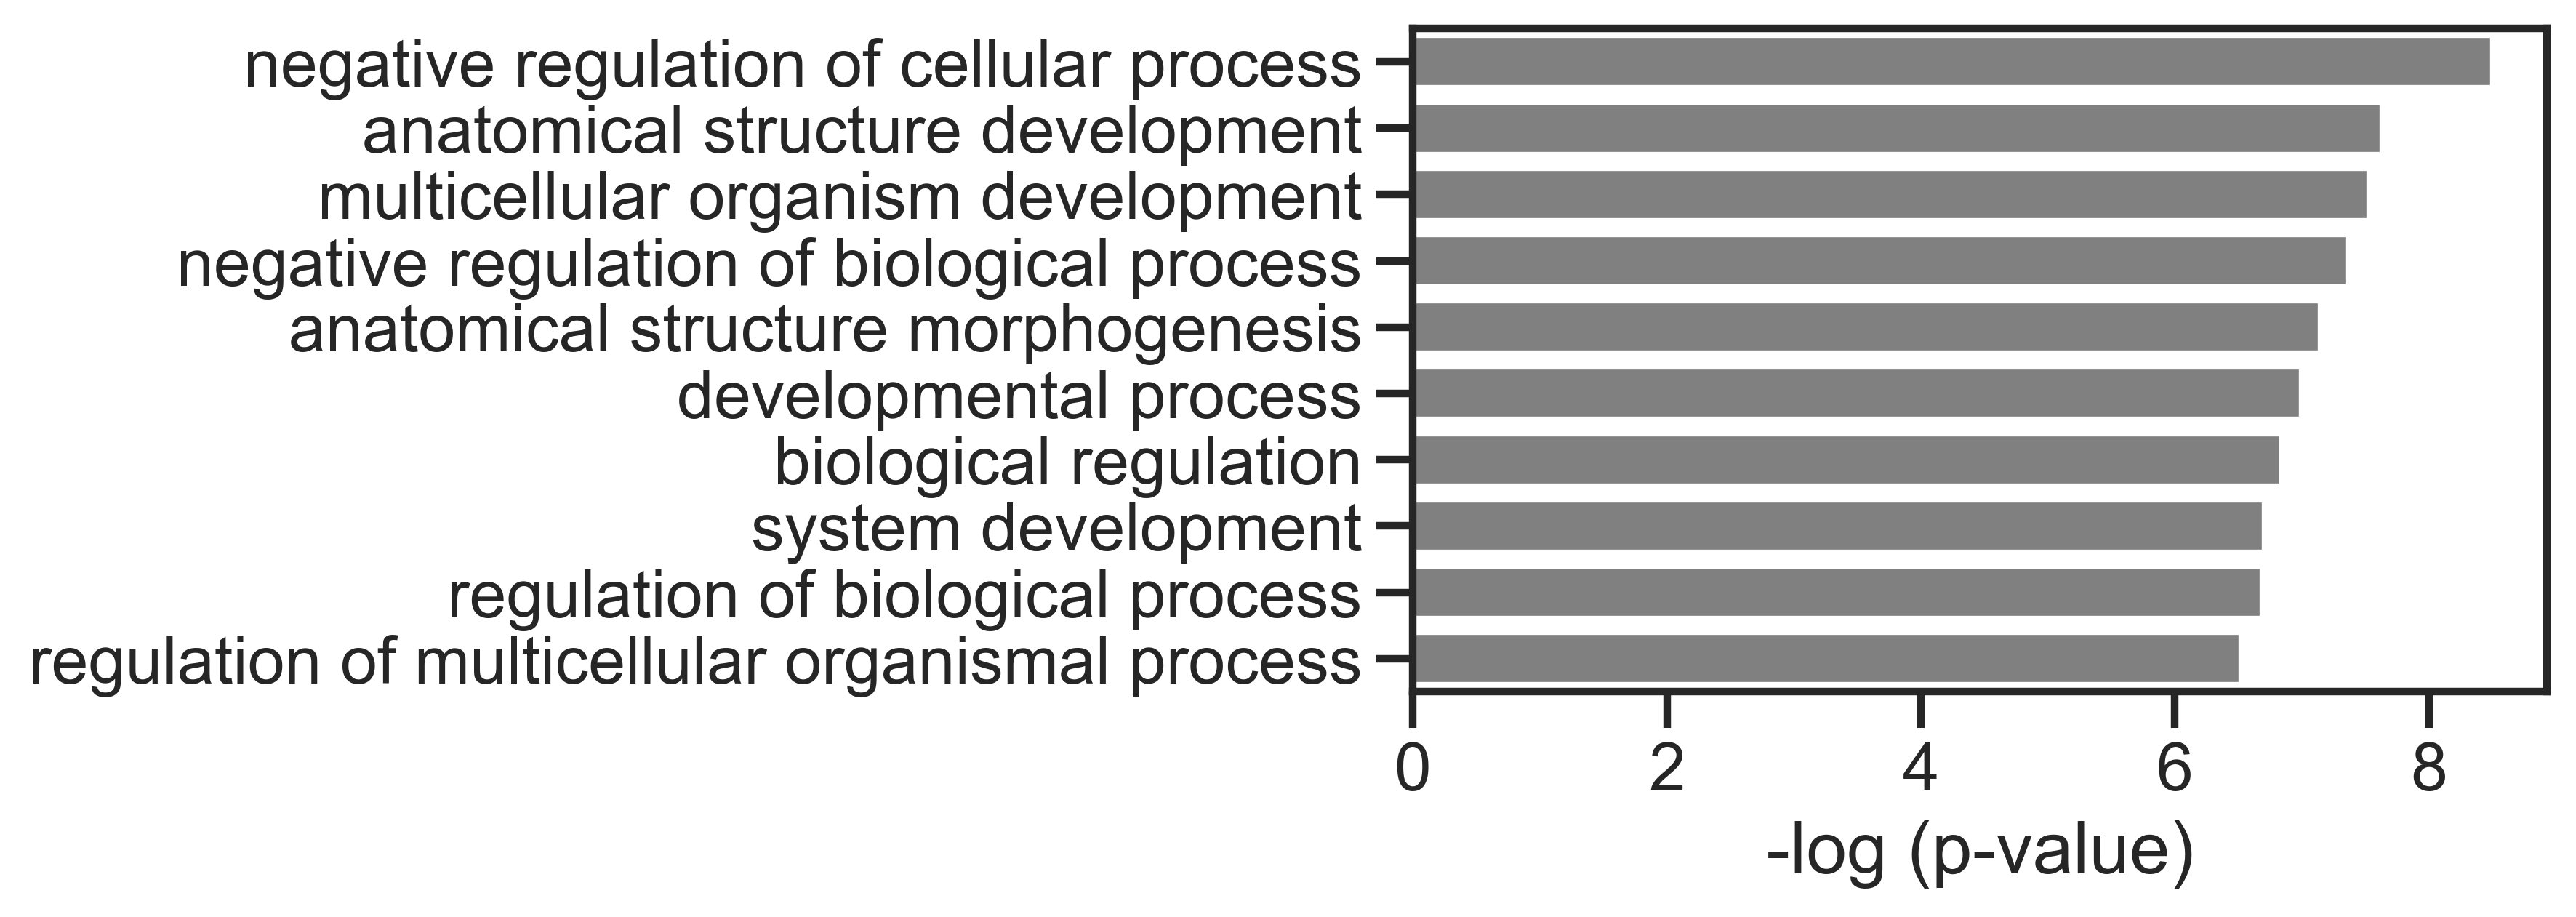

In [127]:
makeGO(test_genes, figsize = (5,3))

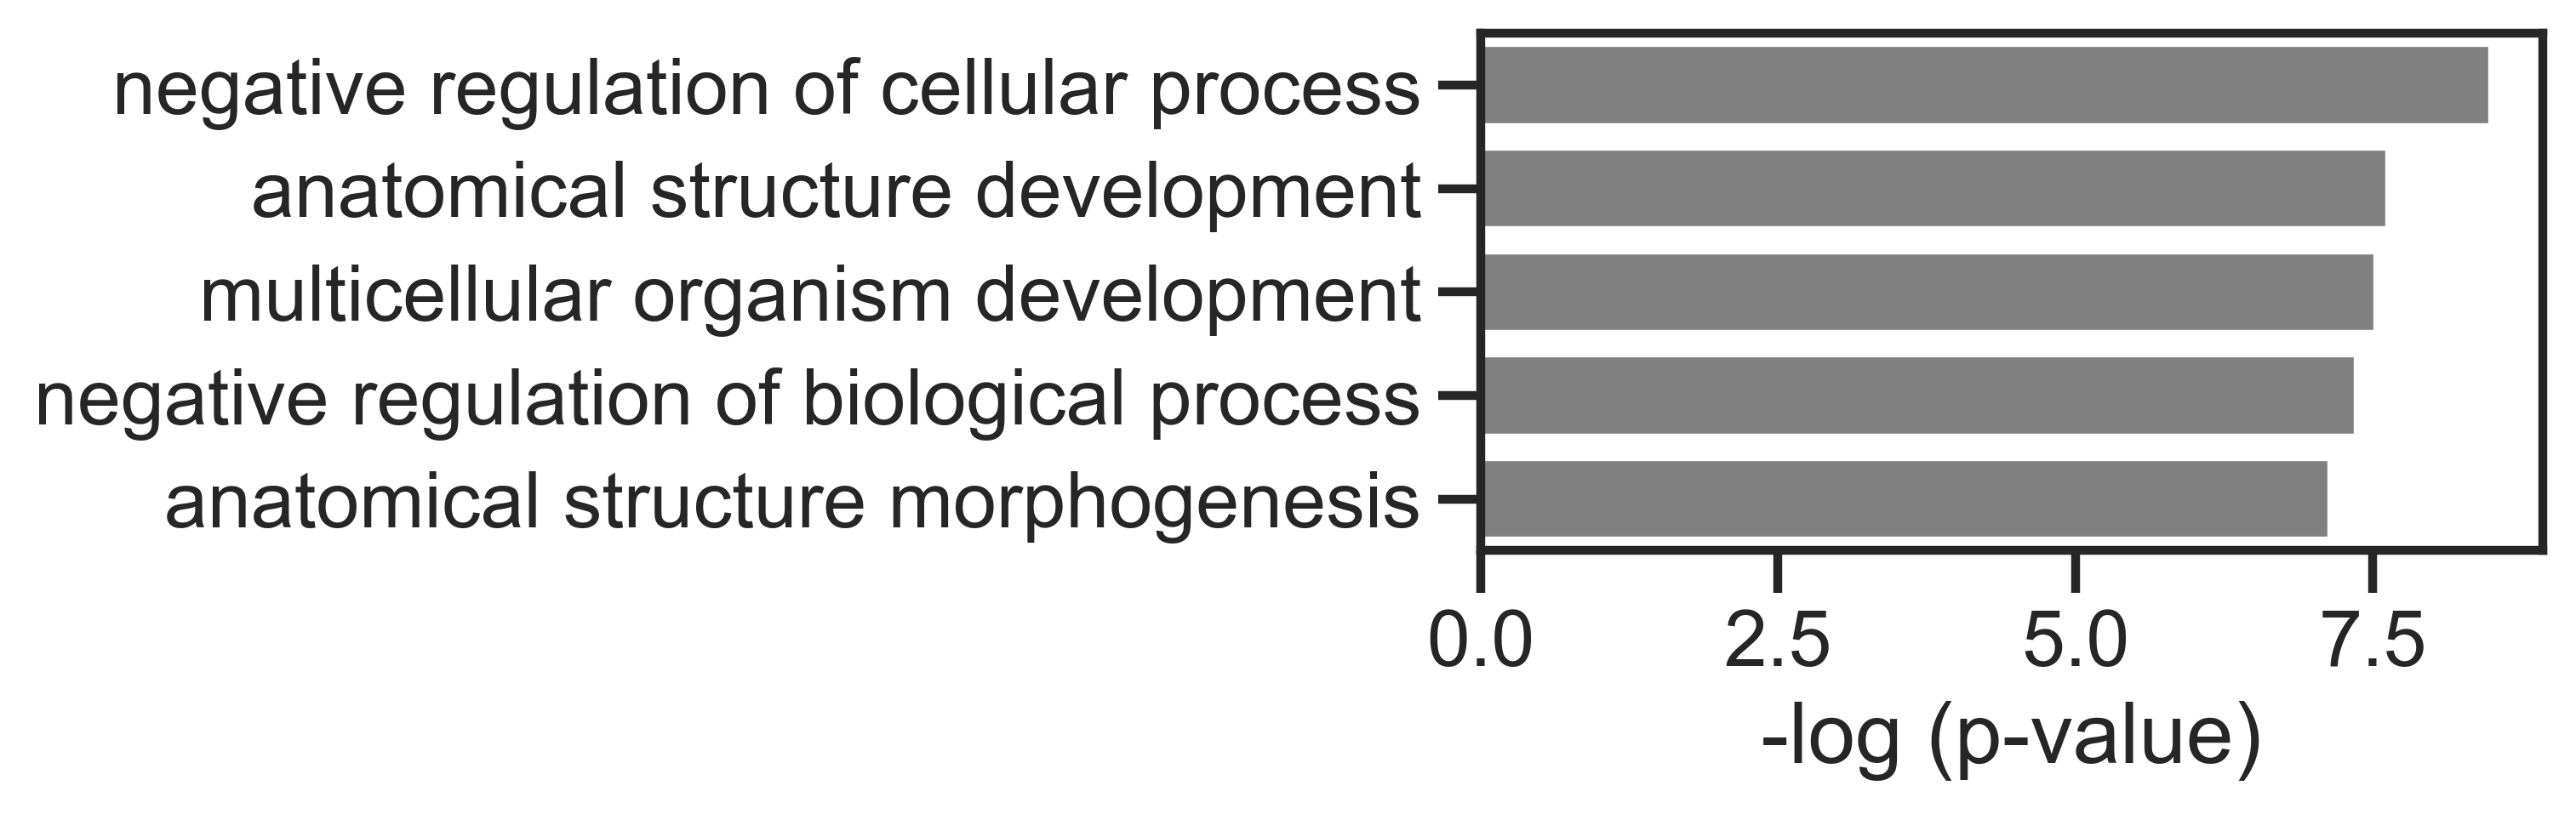

In [126]:
makeGO(test_genes, num = 5)

In [135]:
numTSS = pd.DataFrame(venn_diagram[['Lin','gene']].value_counts()).rename(columns = {0:'count'})

In [138]:
numTSS  = numTSS.reset_index()
numTSS

,Lin,gene,count
0,ESC,Abr,8
1,ESC,Nrxn2,8
2,ESC,Dst,8
3,ESC,Myo10,8
4,ESC,Kdm2b,7
...,...,...,...
68359,END,Slc39a7,1
68360,END,Slc39a8,1
68361,END,Slc39a9,1
68362,END,Slc40a1,1


In [238]:
sumcounts = pd.DataFrame(numTSS[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()


Text(0, 0.5, '# genes')

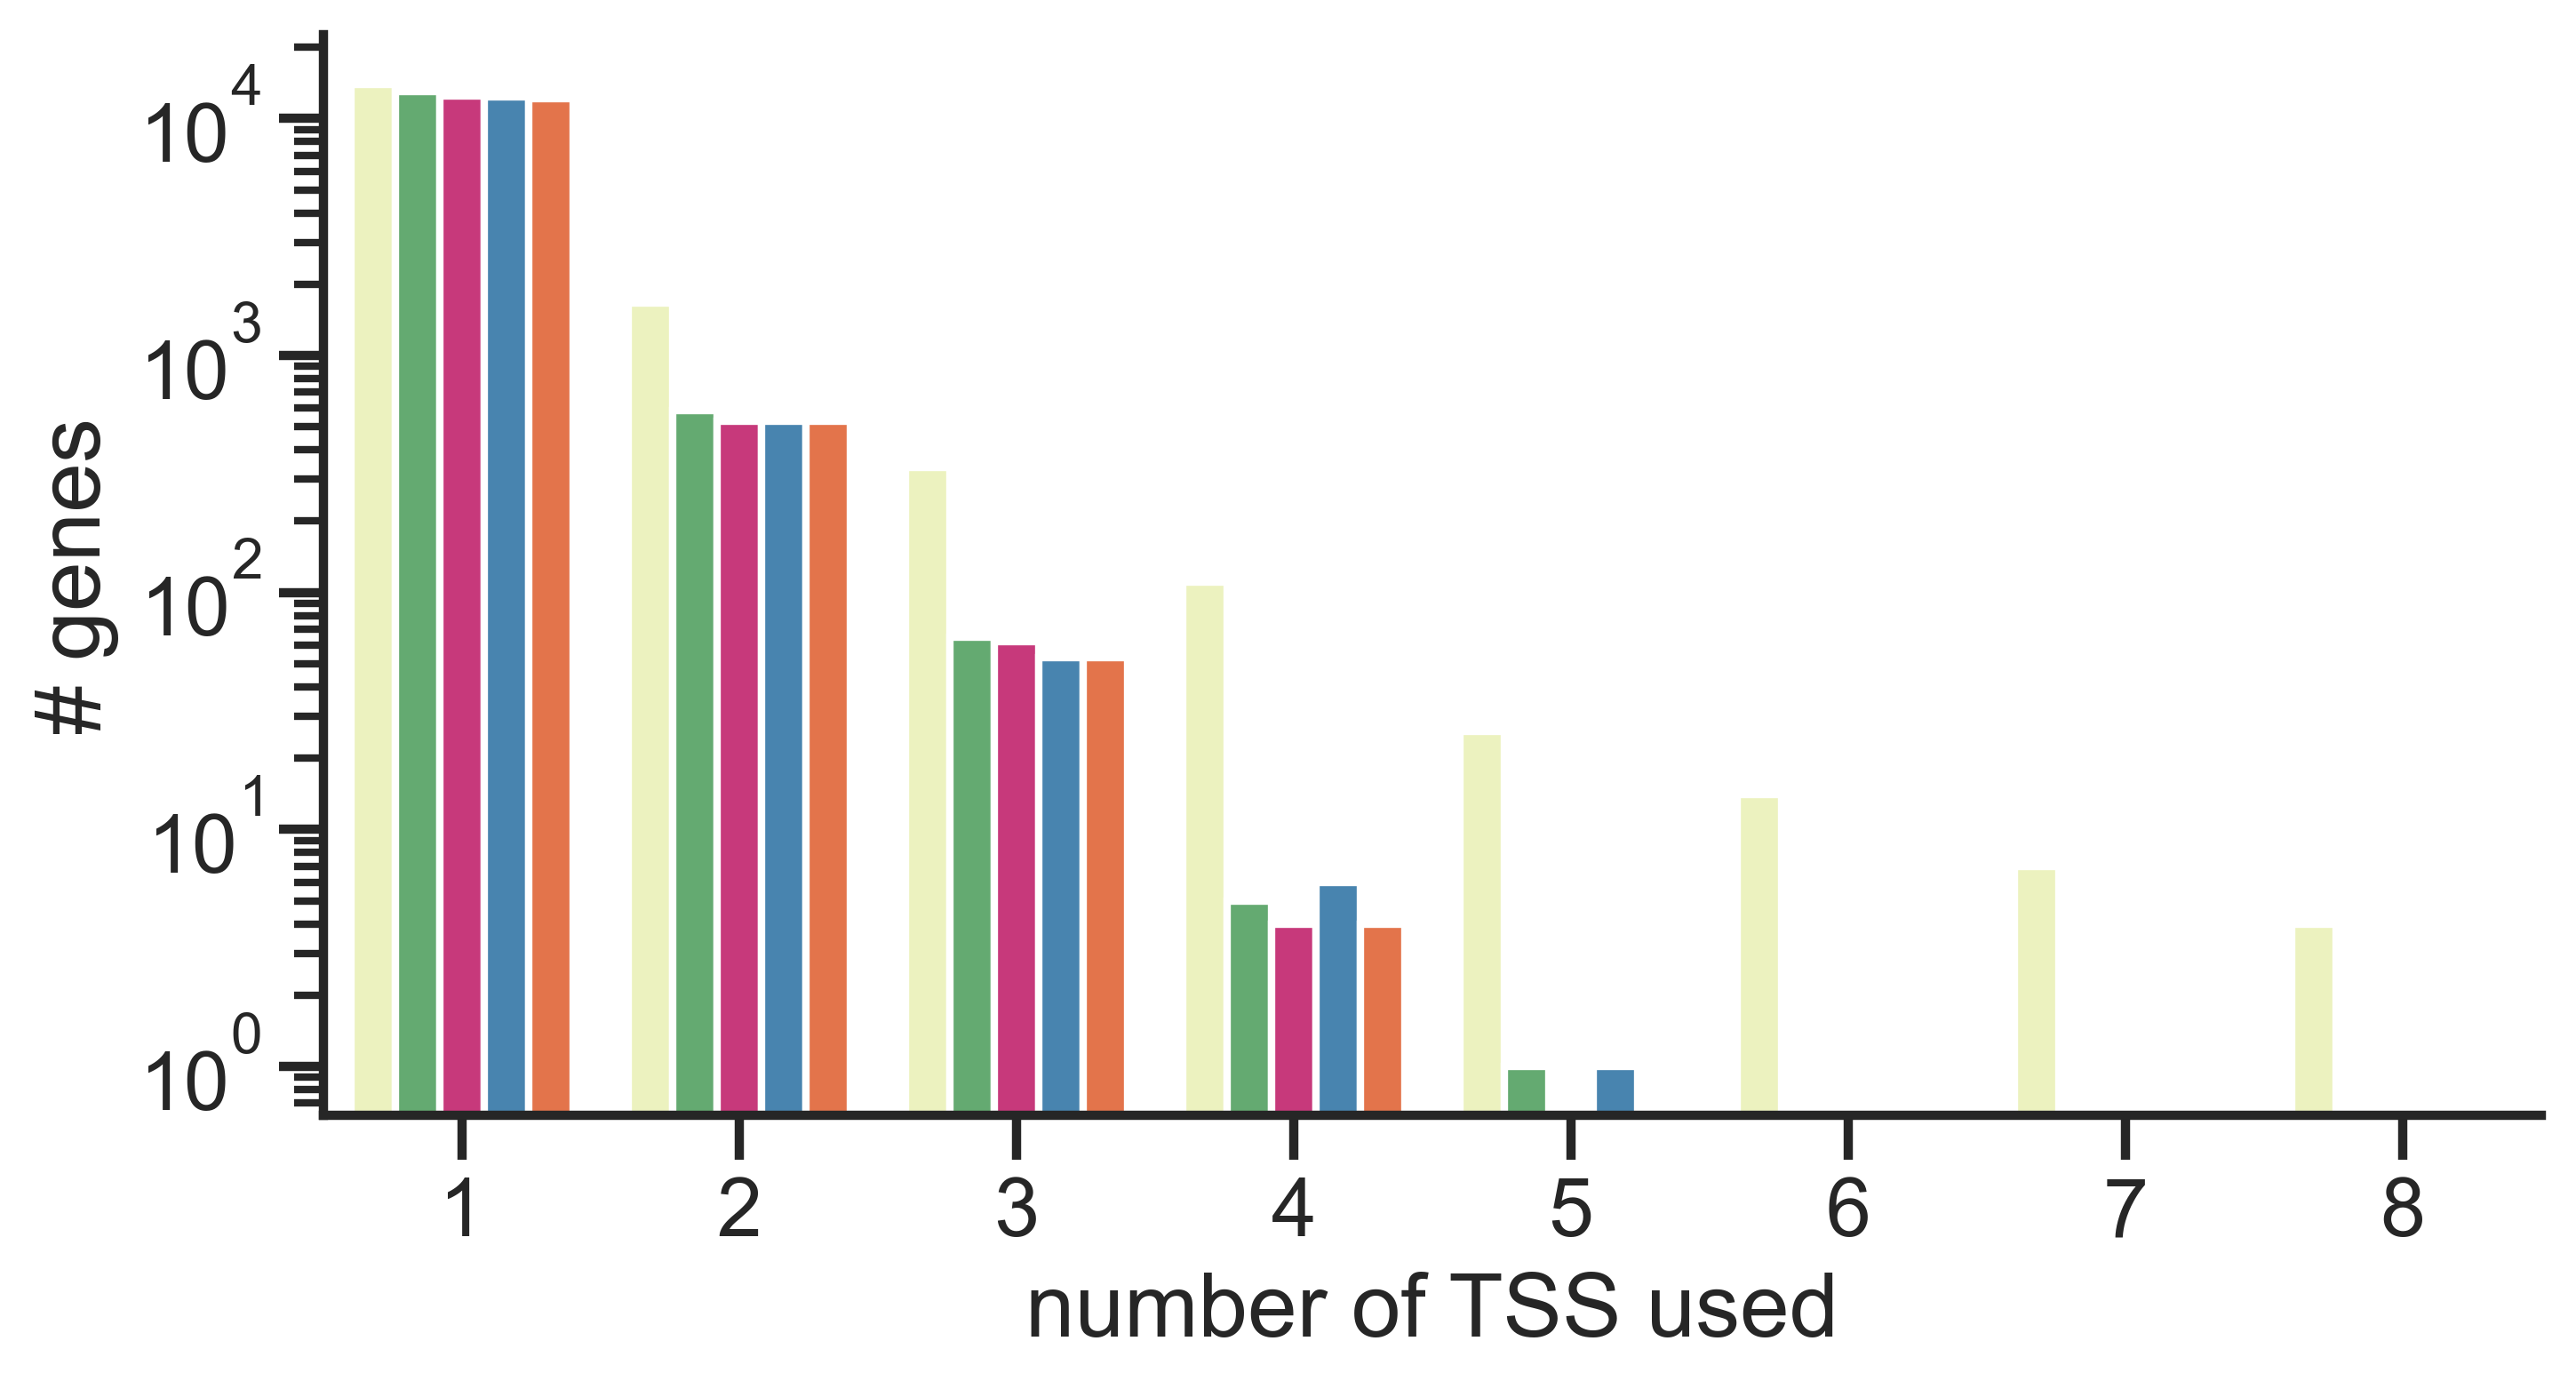

In [269]:
import matplotlib.ticker as ticker

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts['count'], y=sumcounts['sum'],hue=sumcounts['Lin'], ax=ax, palette = ['#f3fab6','#58b669','#df2179','#3787c0', '#fc6832'])
sns.despine()
plt.yscale('log',)
plt.legend([],frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))



Text(0, 0.5, '# genes')

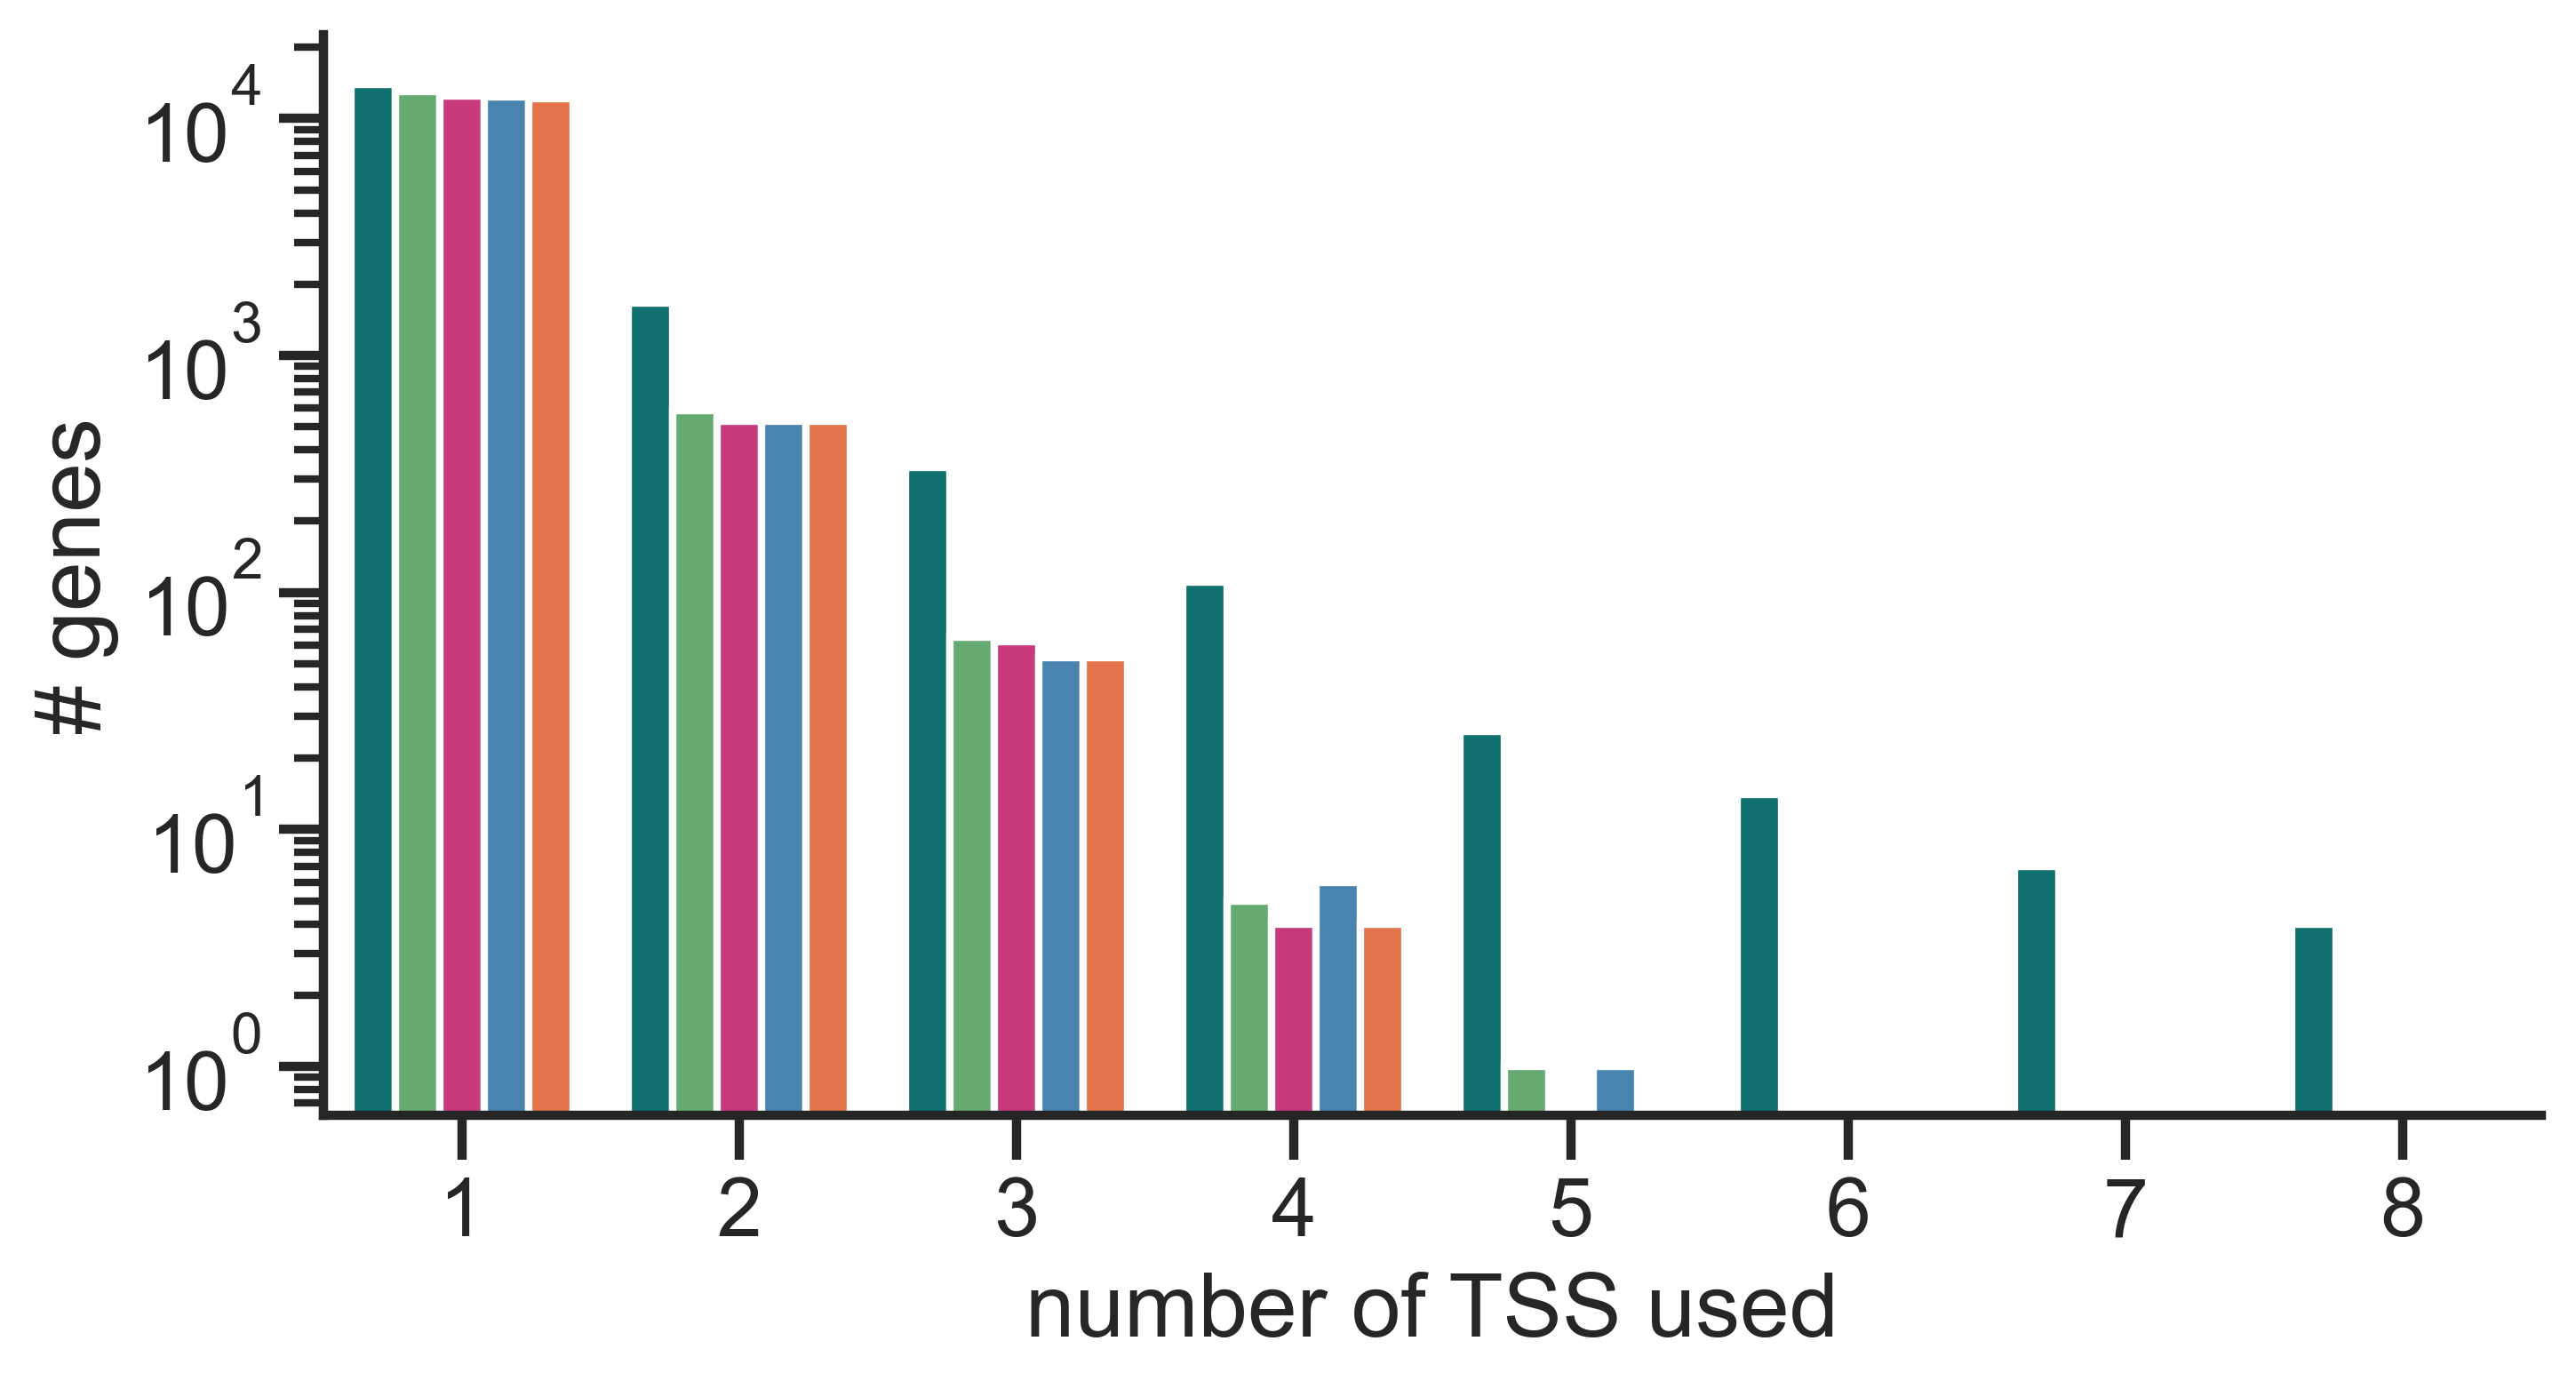

In [274]:
import matplotlib.ticker as ticker

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts['count'], y=sumcounts['sum'],hue=sumcounts['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'])
sns.despine()
plt.yscale('log',)
plt.legend([],frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

